# Predicción de Abandono Escolar y Éxito Académico
### Universidad Nacional — Sede Regional Brunca, Campus Pérez Zeledón
**Curso:** Inteligencia Artificial  
**Profesor:** Pablo Andrés Venegas Elizondo  
**Integrantes:** Altamirano Cordero Deyaneira, Mata Flores Yenifer, Ortiz Molina Jordan

**Fecha:** Junio 2026


## 1. Introducción y Planteamiento del Problema


### 1.1 Introducción

El abandono escolar universitario es un problema que afecta a instituciones 
educativas de todo el mundo. No todos los estudiantes que inician una carrera 
logran terminarla, y las causas pueden ser muy diversas: dificultades 
económicas, bajo rendimiento académico, problemas personales o una combinación 
de todos los factores.

Tradicionalmente, detectar a un estudiante en riesgo dependía de la 
experiencia del personal académico o de que el problema ya fuera visible, 
muchas veces demasiado tarde para intervenir efectivamente.

La Inteligencia Artificial, específicamente el aprendizaje automático 
(Machine Learning), viene a resolver este problema mediante el análisis de patrones en datos 
históricos de estudiantes para predecir, de forma temprana, cuáles tienen 
mayor probabilidad de abandonar. Esto le permite a la institución actuar 
antes de que el abandono ocurra, ya sea mediante apoyo económico, tutoría 
académica u orientación personalizada.

Este proyecto desarrolla un sistema de clasificación que predice si un 
estudiante va a abandonar su carrera, continuar matriculado o graduarse, 
funcionando como una herramienta de apoyo a la toma de decisiones 
institucionales.


### 1.1 Definición del Problema

El problema se clasifica como una tarea de **clasificación supervisada 
multiclase**. A partir de información demográfica, socioeconómica y del 
rendimiento académico del primer y segundo semestre, el modelo predice 
la situación final del estudiante en una de tres categorías:

- **Dropout**: el estudiante abandonó la carrera
- **Enrolled**: el estudiante continúa matriculado activo
- **Graduate**: el estudiante completó y se graduó

**Variables de entrada (features):** las 26 características del dataset,
que incluyen datos demográficos, socioeconómicos y rendimiento académico
de los dos primeros semestres.

**Variable de salida (target):** la columna `Target`, que indica la 
situación final del estudiante.

**Objetivo del modelo:** predecir la categoría más probable para un 
estudiante dado, con el fin de identificar tempranamente casos de riesgo 
de abandono y apoyar la toma de decisiones institucionales.

### 1.2 Tipo de Aprendizaje

Este problema corresponde a **aprendizaje supervisado**, ya que el dataset 
cuenta con ejemplos etiquetados para cada estudiante, ya se conoce el 
resultado final. El modelo aprende a partir de esos ejemplos históricos para luego predecir casos nuevos.

Dentro del aprendizaje supervisado, se trata específicamente de 
**clasificación multiclase**, porque la variable de salida no es un número 
continuo sino una categoría discreta con tres posibles valores.

### 1.3 Variables de entrada y salida

**Variables de entrada (features):** el modelo recibe 36 características 
por estudiante, agrupadas en tres categorías:

- **Demográficas y socioeconómicas:** edad al matricularse, género, 
  nacionalidad, estado civil, si es becado, si tiene deudas de matrícula, 
  ocupación y nivel educativo de los padres, entre otras.

- **Académicas previas al ingreso:** modalidad de aplicación, orden de 
  preferencia, carrera elegida, calificación de admisión y 
  cualificación previa.

- **Rendimiento académico:** unidades curriculares matriculadas, 
  aprobadas, evaluadas y calificaciones del primer y segundo semestre.

**Variable de salida (target):** la columna `Target`, que indica la 
situación final del estudiante en una de tres categorías: `Dropout`, 
`Enrolled` o `Graduate`.

### 1.4 Justificación del Enfoque

Se seleccionaron tres modelos de clasificación con naturalezas 
distintas para abordar el problema:

**Regresión Logística** como modelo base lineal es interpretable, 
eficiente y establece el punto de referencia mínimo que cualquier 
modelo más complejo debe superar.

**Random Forest** como modelo de ensamble paralelo, construye 
múltiples árboles independientes y combina sus resultados, siendo 
robusto ante variables mixtas y útil para identificar qué factores 
influyen más en el abandono.

**XGBoost** como modelo de ensamble secuencial, cada árbol corrige 
los errores del anterior, con mayor potencial para capturar patrones 
complejos e incorpora regularización nativa para controlar el sobreajuste.

XGBoost fue considerado para este trabajo debido a que ha demostrado un alto desempeño en problemas de clasificación, especialmente cuando se combina con otras técnicas de aprendizaje automático. Además, diversos estudios reportan resultados sobresalientes en términos de precisión, sensibilidad y especificidad al emplear este algoritmo en conjuntos de datos médicos (Ramaneswaran et al., 2021).

La comparación entre los tres permite evaluar si la complejidad 
adicional se traduce en una mejora real y cuál generaliza mejor 
a datos nuevos.

#### Configuración inicial
En esta celda se importan las librerías necesarias y se carga el dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Descripción del Dataset



### 2.1 Descripción General


Se utiliza un conjunto de datos proveniente de una institución de educación 
superior de Portugal, creado a partir de múltiples bases de datos 
institucionales y puesto a disposición pública en diciembre de 2021 a través 
del repositorio UCI Machine Learning Repository.

El dataset contiene **4,424 registros** y **37 columnas**, 36 variables 
de entrada y 1 variable objetivo. Cada fila representa un estudiante único 
matriculado en una institución de educación superior de Portugal en 
titulaciones de grado como agronomía, diseño, educación, enfermería, 
periodismo, administración, servicios sociales y tecnologías, entre otras.



### 2.2 Identificación de Variables

A continuación se detalla cada variable del dataset agrupada según 
su naturaleza. Esta clasificación es fundamental para el preprocesamiento, 
ya que cada grupo requiere un tratamiento diferente.

**Variables demográficas y personales**
- `Marital status` — estado civil del estudiante
- `Gender` — género (0: femenino, 1: masculino)
- `Age at enrollment` — edad al momento de matricularse
- `Nacionality` — nacionalidad
- `International` — si es estudiante internacional (0: no, 1: sí)
- `Displaced` — si vive fuera de su lugar de origen (0: no, 1: sí)

**Variables socioeconómicas**
- `Mother's qualification` — nivel educativo de la madre
- `Father's qualification` — nivel educativo del padre
- `Mother's occupation` — ocupación de la madre
- `Father's occupation` — ocupación del padre
- `Scholarship holder` — si posee beca (0: no, 1: sí)
- `Debtor` — si tiene deudas pendientes (0: no, 1: sí)
- `Tuition fees up to date` — si está al día con el pago de matrícula (0: no, 1: sí)
- `Educational special needs` — si tiene necesidades educativas especiales (0: no, 1: sí)
- `Unemployment rate` — tasa de desempleo del país al momento de matrícula
- `Inflation rate` — tasa de inflación
- `GDP` — producto interno bruto

**Variables académicas previas al ingreso**
- `Application mode` — modalidad de aplicación a la carrera
- `Application order` — orden de preferencia de la carrera
- `Course` — carrera matriculada
- `Previous qualification` — nivel de cualificación previa
- `Previous qualification (grade)` — nota de la cualificación previa
- `Admission grade` — nota de admisión
- `Daytime/evening attendance` — si asiste en horario diurno o nocturno

**Rendimiento académico**
- `Curricular units 1st sem (credited)` — unidades reconocidas 1er semestre
- `Curricular units 1st sem (enrolled)` — unidades matriculadas 1er semestre
- `Curricular units 1st sem (evaluations)` — unidades evaluadas 1er semestre
- `Curricular units 1st sem (approved)` — unidades aprobadas 1er semestre
- `Curricular units 1st sem (grade)` — promedio de notas 1er semestre
- `Curricular units 1st sem (without evaluations)` — unidades sin evaluación 1er semestre
- `Curricular units 2nd sem (credited)` — unidades reconocidas 2do semestre
- `Curricular units 2nd sem (enrolled)` — unidades matriculadas 2do semestre
- `Curricular units 2nd sem (evaluations)` — unidades evaluadas 2do semestre
- `Curricular units 2nd sem (approved)` — unidades aprobadas 2do semestre
- `Curricular units 2nd sem (grade)` — promedio de notas 2do semestre
- `Curricular units 2nd sem (without evaluations)` — unidades sin evaluación 2do semestre

**Variable objetivo**
- `Target` — situación final del estudiante: `Dropout`, `Enrolled` o `Graduate`


### 2.3 Análisis exploratorio


#### 2.3.1 Inspección Inicial
Antes de analizar las variables individualmente, se realiza una 
inspección general del dataset para verificar su estructura, tipos 
de datos, valores nulos y registros duplicados.

In [389]:
# Estructura general
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nRegistros duplicados:", df.duplicated().sum())

Dimensiones: (4424, 37)

Tipos de datos:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date        

#### Interpretación

La inspección inicial revela que el dataset está en buenas condiciones 
para el análisis:

**Sin valores nulos:** todas las columnas presentan 4,424 registros 
completos, lo que elimina la necesidad de imputación de datos faltantes.

**Sin duplicados:** no se encontraron registros repetidos, por lo que 
no es necesario eliminar filas.

**Tipos de datos:** se identifica que todas las variables están 
almacenadas como tipos numéricos. Sin embargo, 
no todas representan valores numéricos reales, varias columnas 
contienen códigos enteros que representan categorías. 

#### Estadísticas Descriptivas

Para comprender el comportamiento general de las variables numéricas 
del dataset, se analizan sus estadísticas descriptivas básicas. Esto 
permite identificar rangos de valores, posibles outliers y variables 
con poca variabilidad que podrían no aportar información útil al modelo.

In [390]:
df.describe().round(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


#### Interpretación

El análisis descriptivo revela varios aspectos importantes del dataset:

**Variables con baja variabilidad:** algunas variables presentan un valor 
dominante en la mayoría de registros, lo que podría limitar su capacidad 
predictiva. Los casos más extremos son `Educational special needs` (98.8%), 
`Nacionality` (97.5%) e `International` (97.5%). Estas variables serán 
analizadas en detalle durante el preprocesamiento para evaluar si deben 
ser eliminadas.

**Variables con códigos numéricos:** columnas como `Course`, `Application mode` 
y `Marital status` contienen códigos numéricos que representan categorías, 
no valores continuos. Esto debe considerarse durante el preprocesamiento 
para tratarlas correctamente.

**Variables económicas:** `GDP` presenta valores negativos y `Inflation rate` 
muestra alta variación, lo cual es esperado dado que reflejan condiciones 
macroeconómicas reales del período de estudio.

#### Identificación de Tipos de Variables

Todas las variables están 
almacenadas como tipos numéricos. Sin embargo, no todas representan 
valores numéricos reales, varias columnas contienen códigos enteros 
que representan categorías discretas.

A continuación se verifica la naturaleza de cada variable categórica 
revisando sus valores únicos:

In [391]:
categoricas = [
    'Marital status', 'Application mode', 'Application order',
    'Course', 'Daytime/evening attendance\t', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Displaced',
    'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'International'
]

numericas = [
    'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)'
]

for col in categoricas:
    print(f"{col}: {sorted(df[col].unique())}")

Marital status: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Application mode: [np.int64(1), np.int64(2), np.int64(5), np.int64(7), np.int64(10), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(26), np.int64(27), np.int64(39), np.int64(42), np.int64(43), np.int64(44), np.int64(51), np.int64(53), np.int64(57)]
Application order: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9)]
Course: [np.int64(33), np.int64(171), np.int64(8014), np.int64(9003), np.int64(9070), np.int64(9085), np.int64(9119), np.int64(9130), np.int64(9147), np.int64(9238), np.int64(9254), np.int64(9500), np.int64(9556), np.int64(9670), np.int64(9773), np.int64(9853), np.int64(9991)]
Daytime/evening attendance	: [np.int64(0), np.int64(1)]
Previous qualification: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64

#### Interpretación

Se identifican dos grupos de variables según su naturaleza real:

**Variables categóricas (18) :** almacenadas como enteros pero representan 
categorías discretas. Dentro de este grupo existen dos subtipos:
- **Binarias:** `Gender`, `Displaced`, `Debtor`, `Tuition fees up to date`, 
  `Scholarship holder`, `International`, `Educational special needs` y 
  `Daytime/evening attendance` las cuales usan códigos 0 y 1.
- **Multiclase:** `Marital status`, `Course`, `Application mode`, 
  `Nacionality`, `Mother's occupation`, `Father's occupation`, entre otras 
  que usan múltiples códigos enteros para representar categorías distintas.

**Variables numéricas (16):** representan valores continuos reales como 
notas, edad, tasas económicas y conteos de unidades curriculares.

Cada grupo 
requiere un tratamiento diferente en el pipeline de transformación.

#### 2.3.2 Análisis Univariado

#### Distribución de la variable objetivo

Antes de cualquier análisis, es fundamental entender cómo se distribuyen 
las clases de la variable objetivo. Un desbalance significativo entre clases 
afecta directamente la elección de métricas de evaluación y la estrategia 
de entrenamiento de los modelos.

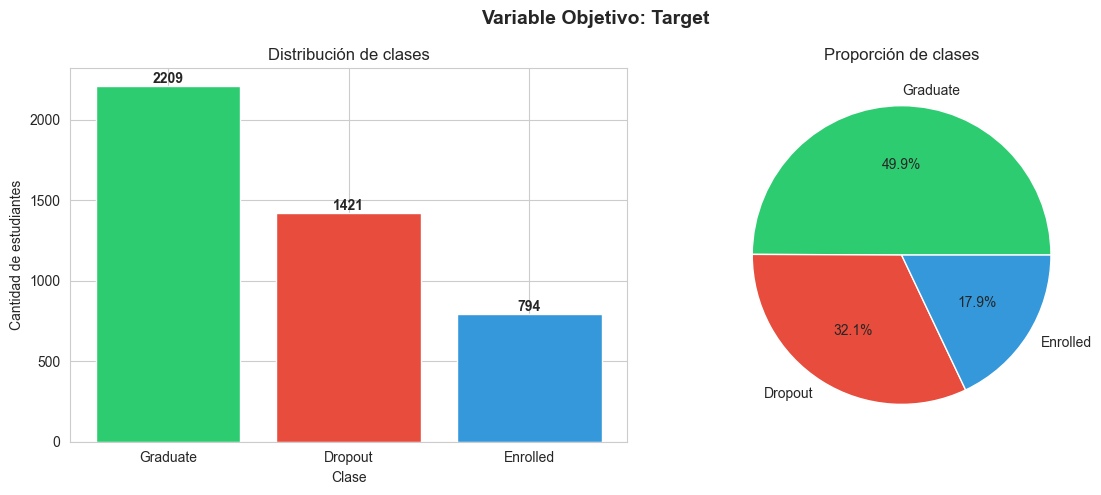

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [392]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
conteo = df['Target'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('Distribución de clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de estudiantes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title('Proporción de clases')

plt.suptitle('Variable Objetivo: Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(conteo)

#### Interpretación

El dataset presenta un desbalance de clases considerable. La clase 
**Graduate** domina con un 49.9% de los registros, seguida de **Dropout** 
con 32.1% y **Enrolled** con apenas 17.9%.

Este desbalance es relevante porque un modelo que predijera "Graduate" 
para todos los estudiantes obtendría un 49.9% de accuracy sin haber 
aprendido nada útil, casi la mitad de aciertos garantizados por la 
distribución del dataset, no por el aprendizaje del modelo. Esto hace 
que el accuracy no sea una métrica confiable para evaluar el desempeño 
en este problema.

Por esta razón se tomarán dos decisiones técnicas:
- Se utilizará el **F1-score macro** como métrica principal, ya que 
  evalúa el desempeño en cada clase por separado con igual peso, 
  independientemente de su frecuencia.
- Se aplicará **class_weight='balanced'** durante el entrenamiento, 
  para que los modelos no aprendan a favorecer la clase mayoritaria.

#### Distribución de Variables Numéricas Continuas

Se analizan las distribuciones de las variables numéricas continuas 
del dataset para identificar asimetrías, outliers y rangos de valores. 
Esto informa las decisiones de escalamiento durante el preprocesamiento.

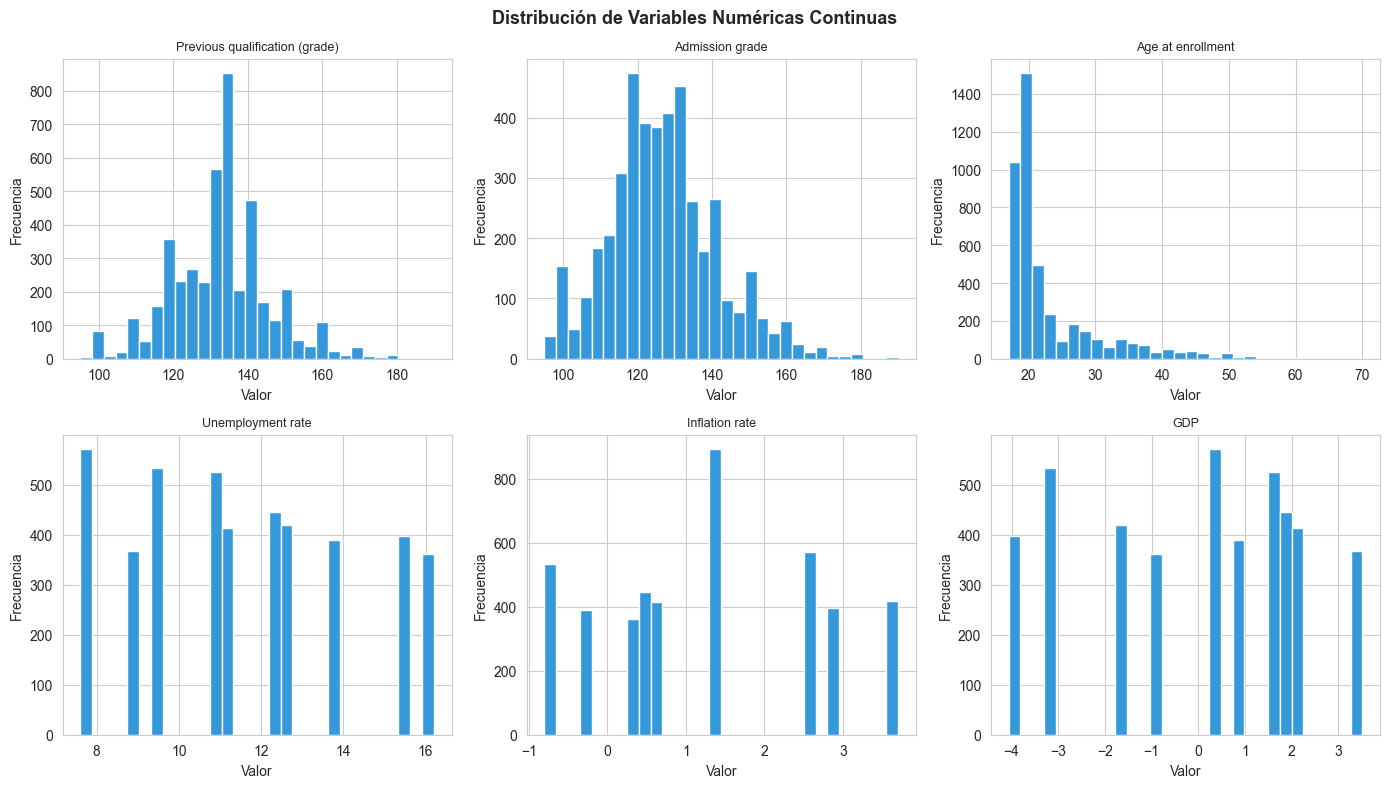

In [393]:
# Variables numéricas continuas generales
continuas = ['Previous qualification (grade)', 'Admission grade',
             'Age at enrollment', 'Unemployment rate', 
             'Inflation rate', 'GDP']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(continuas):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Continuas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Notas de admisión y cualificación previa:** ambas presentan distribuciones 
aproximadamente normales concentradas entre 120 y 150, lo que sugiere 
un proceso de admisión con criterios consistentes. La similitud entre 
ambas distribuciones indica que los estudiantes ingresan con un perfil 
académico previo relativamente homogéneo.

**Edad al matricularse:** la distribución está fuertemente concentrada 
entre 17 y 25 años con una cola larga hacia edades mayores. La presencia 
de estudiantes mayores de 40 años podría representar un perfil con 
dinámicas de abandono distintas, asociadas a responsabilidades laborales 
o familiares.

**Variables macroeconómicas (Unemployment rate, Inflation rate, GDP):** 
las tres presentan distribuciones discretas con pocos valores únicos. 
Esto se debe a que reflejan el contexto económico del país en períodos 
específicos, varios estudiantes comparten el mismo valor por haber 
ingresado en el mismo año. 

#### Distribución de Variables Académicas

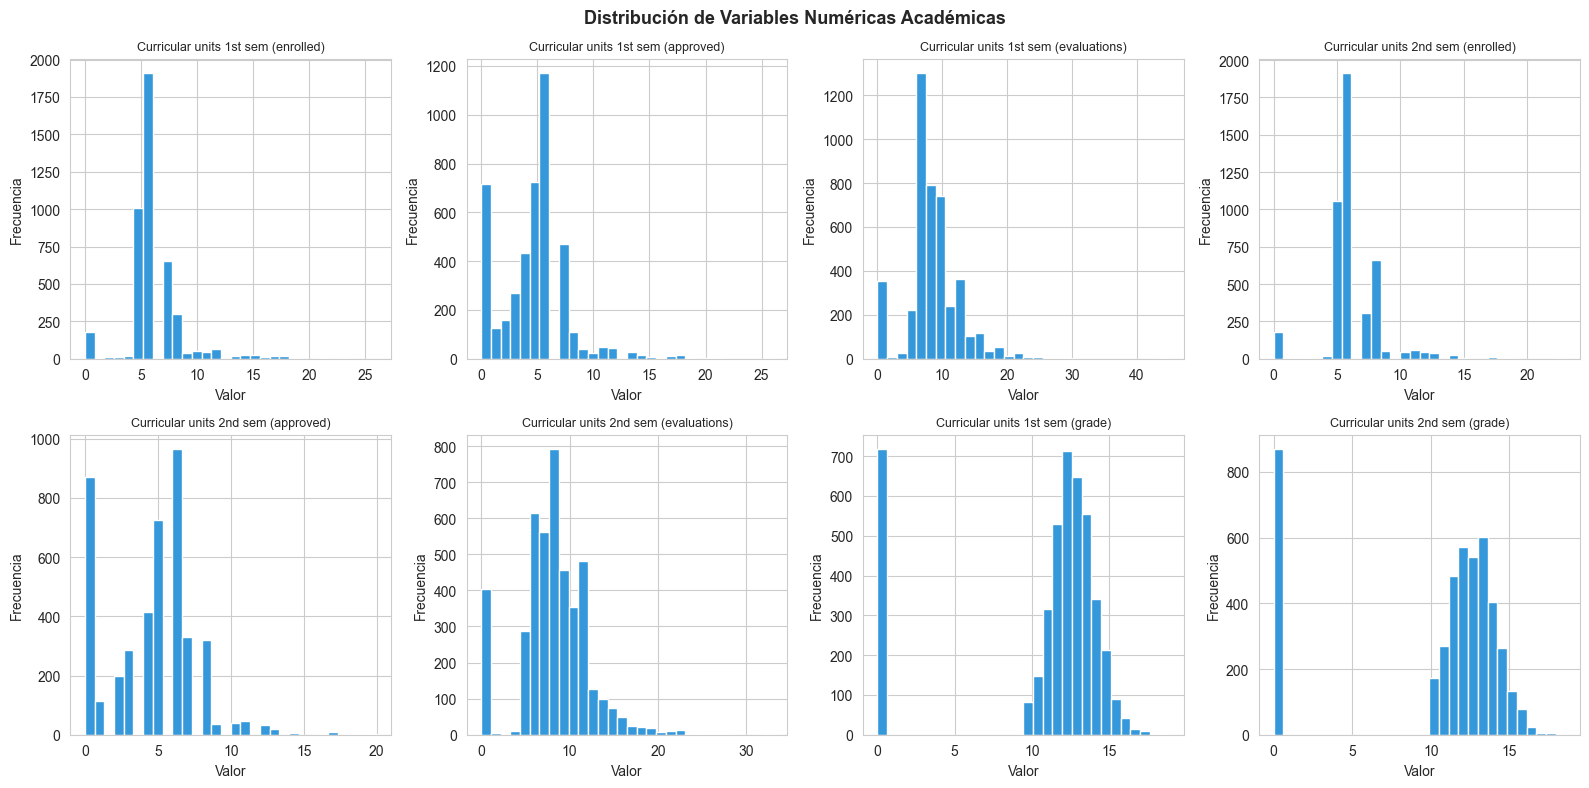

In [394]:
academicas = [
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (grade)',
             'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(academicas):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Académicas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Unidades matriculadas (enrolled):** tanto en el primer como en el 
segundo semestre, la mayoría de estudiantes se matricula en 6 materias, 
con una distribución similar entre ambos semestres. Esto sugiere una 
carga académica estándar para la mayoría.

**Unidades aprobadas (approved):** esta es la variable más reveladora. 
Se observan dos grupos claramente distintos, un grupo que aprueba 
entre 5 y 6 materias, y un grupo significativo con 0 materias aprobadas. 
Esta bimodalidad sugiere una división clara entre estudiantes que 
avanzan normalmente y estudiantes en riesgo de abandono. En el segundo 
semestre el pico en 0 es proporcionalmente mayor, lo que podría indicar 
que quienes no aprobaron en el primero tampoco logran recuperarse.

**Unidades evaluadas (evaluations):** la mayoría fue evaluada entre 
8 y 10 veces, sin embargo el pico inicial en valores bajos sugiere 
estudiantes que dejaron de presentarse a evaluaciones, comportamiento 
consistente con abandono temprano.

**Notas del semestre (grade):** el pico prominente en 0 confirma lo 
observado en approved, un grupo importante de estudiantes termina 
el semestre sin ninguna nota aprobatoria. Estas variables junto con 
approved serán probablemente las más predictivas para el modelo.

#### Variables Categóricas

Se analiza la distribución de las variables categóricas principales 
para identificar desbalances y categorías dominantes que puedan 
afectar el modelo.

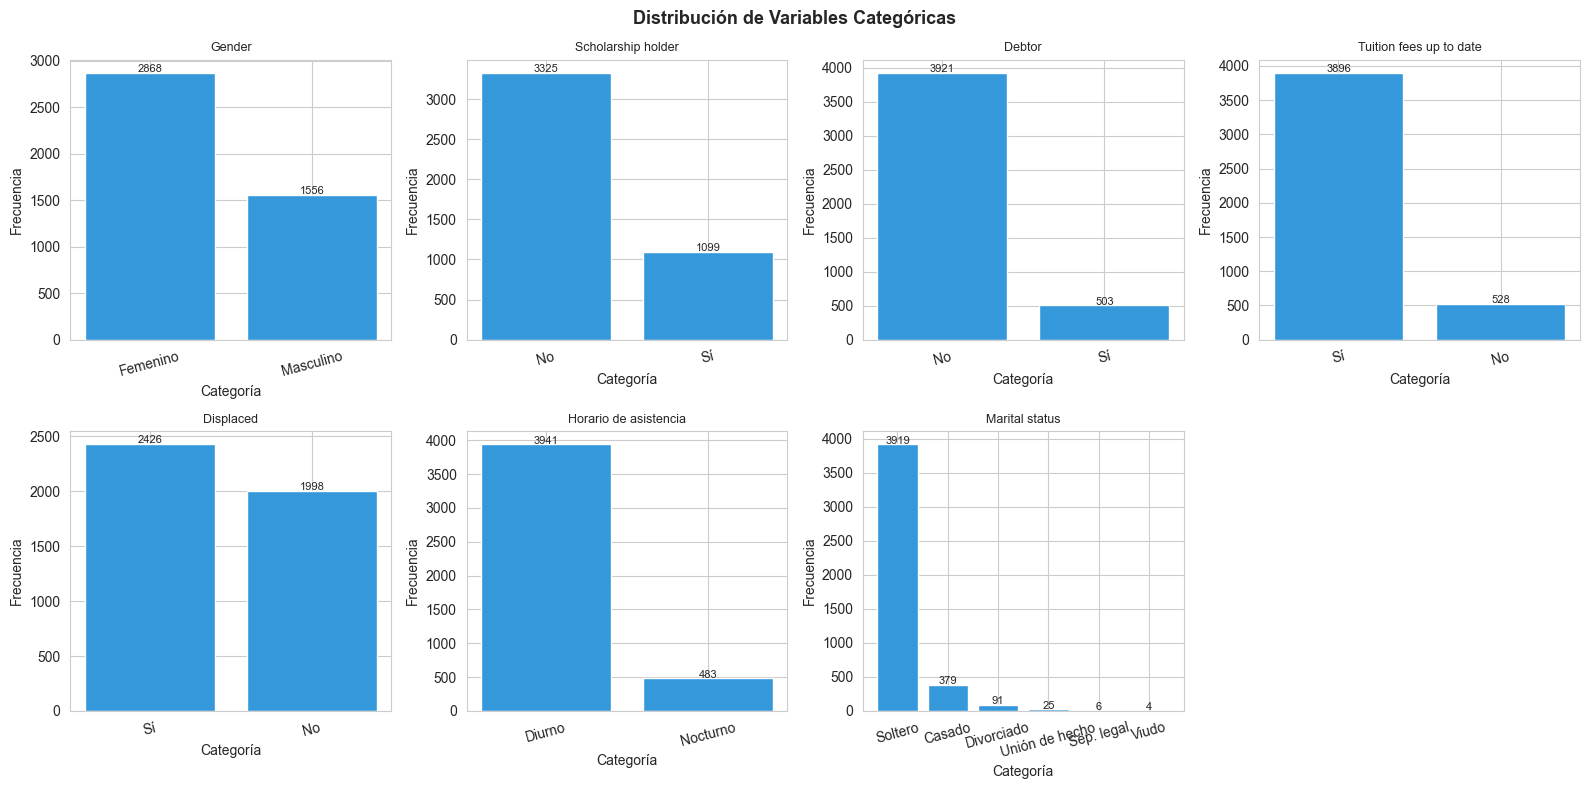

In [395]:
# Mapeo de códigos a etiquetas legibles
mapeos = {
    'Gender': {0: 'Femenino', 1: 'Masculino'},
    'Scholarship holder': {0: 'No', 1: 'Sí'},
    'Debtor': {0: 'No', 1: 'Sí'},
    'Tuition fees up to date': {0: 'No', 1: 'Sí'},
    'Displaced': {0: 'No', 1: 'Sí'},
    'Daytime/evening attendance\t': {0: 'Nocturno', 1: 'Diurno'},
    'Marital status': {1: 'Soltero', 2: 'Casado', 3: 'Viudo', 
                       4: 'Divorciado', 5: 'Unión de hecho', 
                       6: 'Sep. legal'}
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(mapeos.keys()):
    datos = df[col].map(mapeos[col]).value_counts()
    axes[i].bar(datos.index, datos.values, color='#3498db')
    axes[i].set_title(col.replace('Daytime/evening attendance\t', 
                      'Horario de asistencia'), fontsize=9)
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(datos.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribución de Variables Categóricas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

La mayoría de estudiantes son mujeres, solteras, asisten en horario 
diurno y no tienen deudas ni problemas con el pago de matrícula.

Los aspectos más relevantes para el modelo son:

**Beca:** solo el 24.8% de estudiantes tiene beca. Este grupo es 
importante porque perder la beca por bajo rendimiento puede 
convertirse en un factor acelerador del abandono.

**Dificultades económicas:** los estudiantes con deudas o que no 
están al día con la matrícula son minoría, pero representan un 
grupo de riesgo directo para el abandono.

**Horario nocturno:** los 483 estudiantes nocturnos frecuentemente 
combinan trabajo y estudio, lo que puede afectar negativamente 
su rendimiento académico.

**Estado civil:** el dominio casi absoluto de solteros (3,919 de 4,424) 
sugiere que esta variable tendrá poca capacidad discriminativa 
para el modelo, será candidata a eliminación en el preprocesamiento.

#### Detección de Outliers

Se utilizan diagramas de caja (boxplots) para identificar valores 
atípicos en las variables numéricas continuas. Los outliers pueden 
afectar el entrenamiento del modelo y deben ser analizados para 
decidir si representan errores o casos reales válidos.

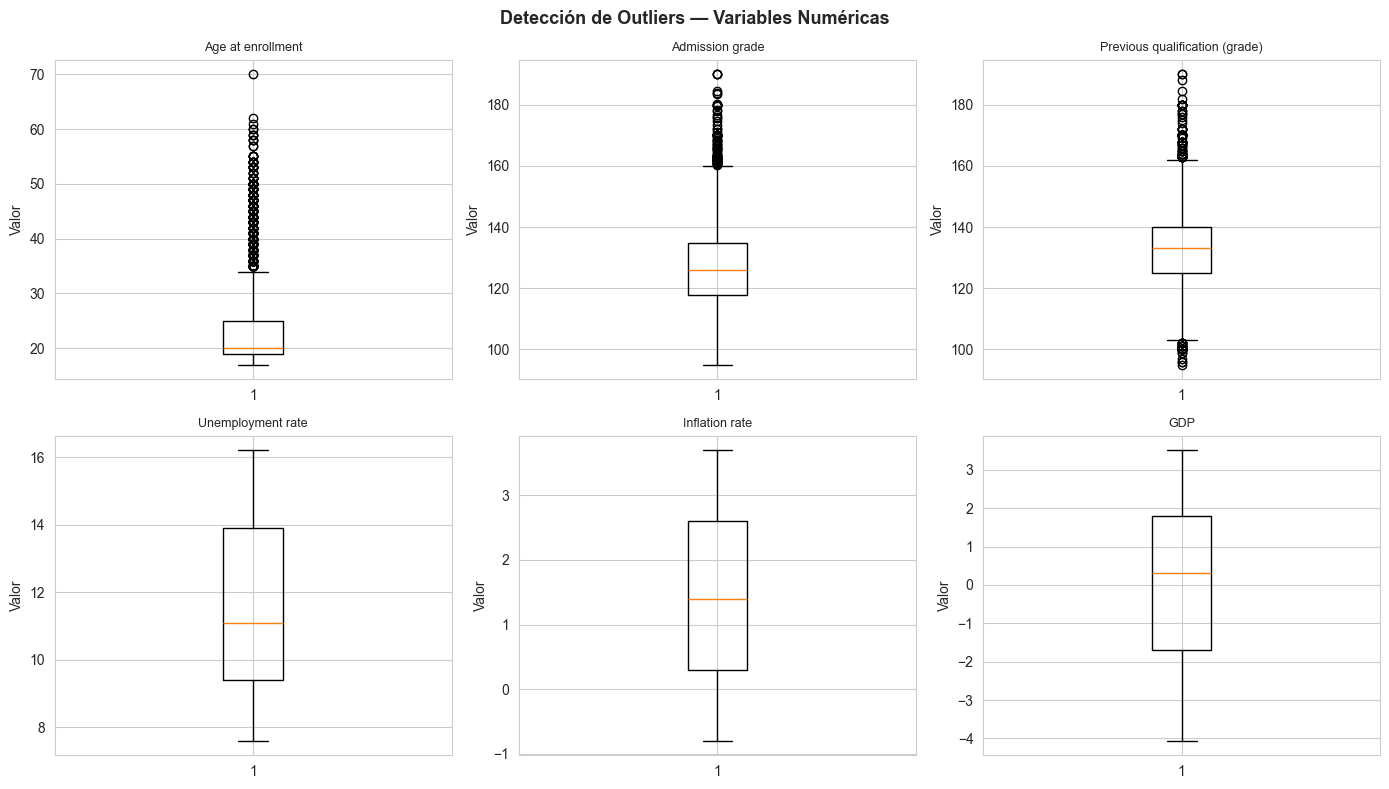

In [396]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

outlier_vars = ['Age at enrollment', 'Admission grade',
                'Previous qualification (grade)',
                'Unemployment rate', 'Inflation rate', 'GDP']

for i, col in enumerate(outlier_vars):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Valor')

plt.suptitle('Detección de Outliers — Variables Numéricas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

El análisis de boxplots revela la presencia de valores atípicos en 
las variables académicas y de edad:

**Edad al matricularse:** la mayoría de estudiantes tiene entre 19 y 
25 años, sin embargo se identifican casos de estudiantes mayores de 
40, 50 e incluso 70 años. Estos valores son outliers estadísticos 
pero representan casos reales y válidos — estudiantes que retoman 
sus estudios en edad adulta. No se eliminan.

**Notas de admisión y cualificación previa:** la mayoría se concentra 
entre 120 y 140 puntos, con algunos casos excepcionales cercanos a 
190. Estas notas altas son perfectamente posibles dentro de la escala 
0-200 del sistema educativo portugués. No se eliminan.

**Variables macroeconómicas:** no se identifican outliers en tasa de 
desempleo, inflación ni GDP — sus distribuciones son consistentes 
con variaciones económicas reales del período de estudio.

En general, los outliers encontrados no representan errores de datos 
sino perfiles reales de estudiantes. Eliminarlos podría sesgar el 
modelo hacia un perfil estudiantil único, perdiendo capacidad 
predictiva para casos atípicos pero válidos.

#### 2.3.3 Análisis Multivariado

#### Relación entre Variables Académicas y la Variable Objetivo

Se analiza cómo se distribuyen las variables académicas según la 
situación final del estudiante. Esto permite identificar qué variables 
tienen mayor capacidad para discriminar entre las tres clases y 
orientar las decisiones de modelado.

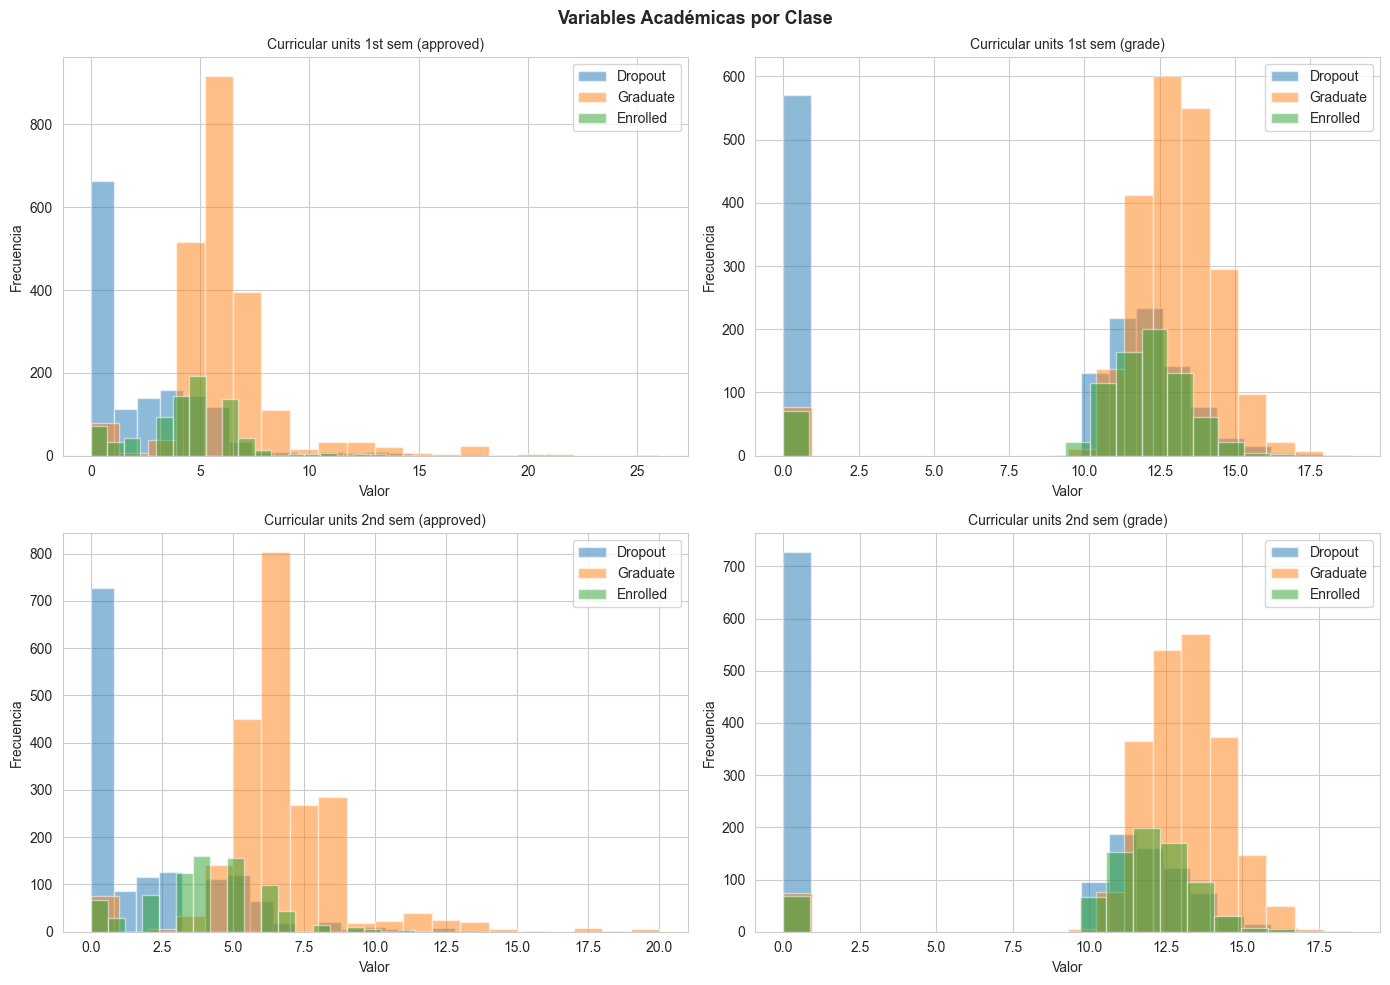

In [397]:
academicas_target = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(academicas_target):
    for target in df['Target'].unique():
        subset = df[df['Target'] == target][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=target)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Variables Académicas por Clase', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

Los gráficos revelan una separación muy clara entre las tres clases,
lo que confirma que el rendimiento académico es el factor más 
discriminante para predecir la situación final del estudiante.

**Materias aprobadas:** en ambos semestres se observa un patrón 
consistente — los estudiantes con 0 materias aprobadas corresponden 
casi exclusivamente a la clase Dropout, mientras que los estudiantes 
que aprueban entre 5 y 6 materias pertenecen predominantemente a 
Graduate. La clase Enrolled se distribuye en valores intermedios, 
lo que tiene sentido ya que son estudiantes que aún continúan su 
proceso académico.

**Promedio de notas:** el patrón se repite — Dropout se concentra 
en nota 0, mientras que Graduate y Enrolled presentan notas entre 
10 y 15. La separación es tan marcada que prácticamente no hay 
superposición entre Dropout y las otras dos clases.

**Comparación entre semestres:** el pico de Dropout en 0 es 
proporcionalmente mayor en el segundo semestre que en el primero, 
lo que sugiere que los estudiantes que no logran recuperarse del 
bajo rendimiento del primer semestre tienen una probabilidad muy 
alta de abandonar.

Estas cuatro variables serán probablemente las más importantes 
para ambos modelos y se espera que tengan alto peso en la 
predicción final.

#### Relación entre Variables Socioeconómicas y la Variable Objetivo

Se analiza si factores como la beca, deudas y situación económica 
del país están asociados con la situación final del estudiante.

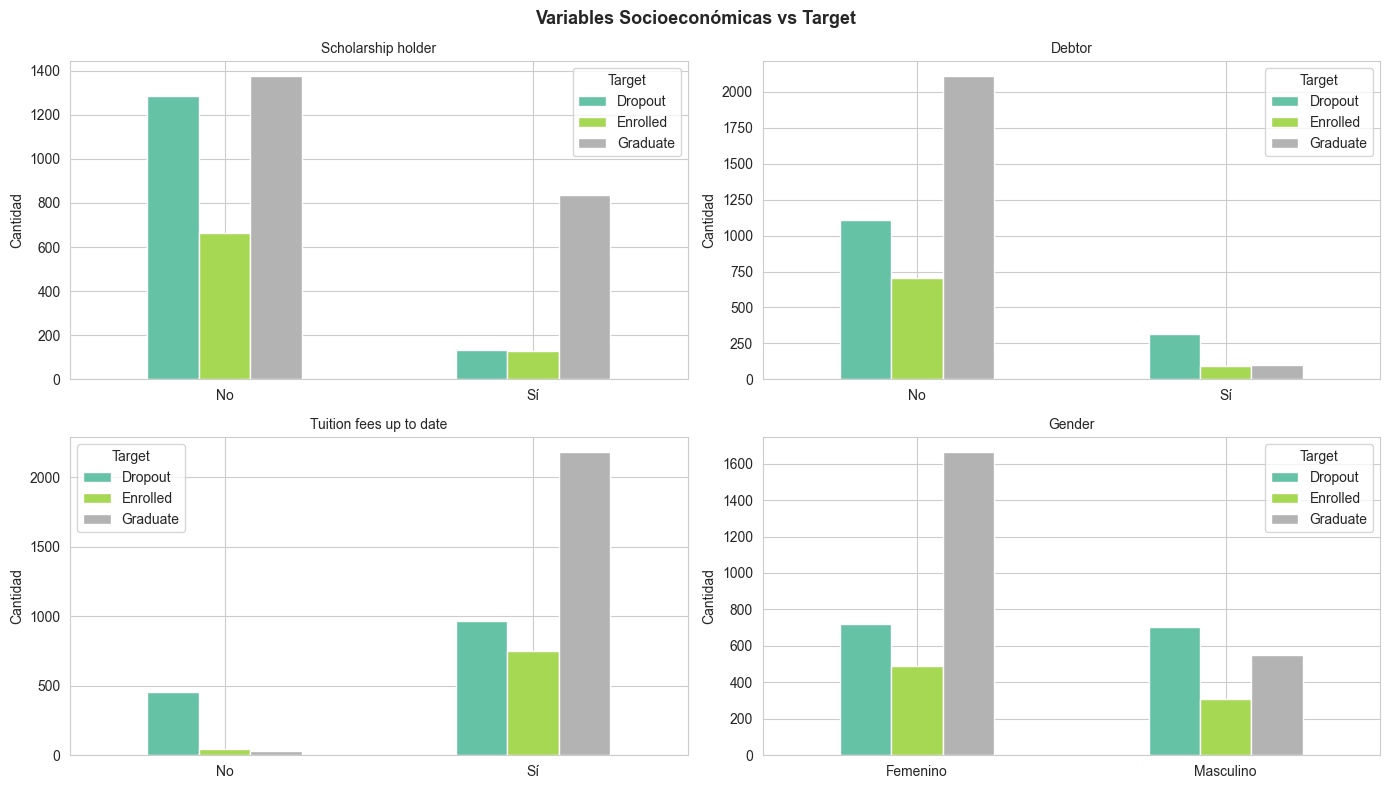

In [398]:
socioeconomicas = ['Scholarship holder', 'Debtor', 
                   'Tuition fees up to date', 'Gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

mapeos_plot = {
    'Scholarship holder': {0: 'No', 1: 'Sí'},
    'Debtor': {0: 'No', 1: 'Sí'},
    'Tuition fees up to date': {0: 'No', 1: 'Sí'},
    'Gender': {0: 'Femenino', 1: 'Masculino'}
}

for i, col in enumerate(socioeconomicas):
    datos = df.groupby([col, 'Target']).size().unstack()
    datos.index = datos.index.map(mapeos_plot[col])
    datos.plot(kind='bar', ax=axes[i], colormap='Set2')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Target')

plt.suptitle('Variables Socioeconómicas vs Target', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Pago de matrícula al día:** es la variable más reveladora de este 
análisis. Los estudiantes que no están al día con el pago muestran 
una proporción de Dropout muy alta comparada con Graduate, mientras 
que los que SÍ están al día tienen Graduate como clase dominante. 
Esto sugiere que las dificultades económicas son un predictor 
directo del abandono.

**Deudas:** un patrón similar, los estudiantes con deudas tienen 
una proporción de Dropout notablemente mayor que los que no deben. 
Confirma que la situación económica está fuertemente asociada 
con el abandono.

**Beca:** los estudiantes con beca tienen una proporción de Graduate 
mayor que los sin beca, lo que sugiere que el apoyo económico 
institucional tiene un efecto protector contra el abandono.

**Género:** no se observan diferencias significativas entre femenino 
y masculino en cuanto a la distribución de clases, lo que indica 
que el género por sí solo no es un predictor relevante del abandono.

#### Correlación de Variables con la Variable Objetivo

Para complementar los análisis anteriores y orientar las decisiones 
de preprocesamiento, se calcula la correlación absoluta de cada variable 
con la variable objetivo codificada numéricamente. Esto permite identificar 
de forma global qué variables tienen mayor capacidad predictiva y cuáles 
no aportan información relevante al modelo.

C:\Users\USUARIO UNA PZ\AppData\Local\Temp\ipykernel_24516\1478169315.py:9: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USUARIO UNA PZ\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


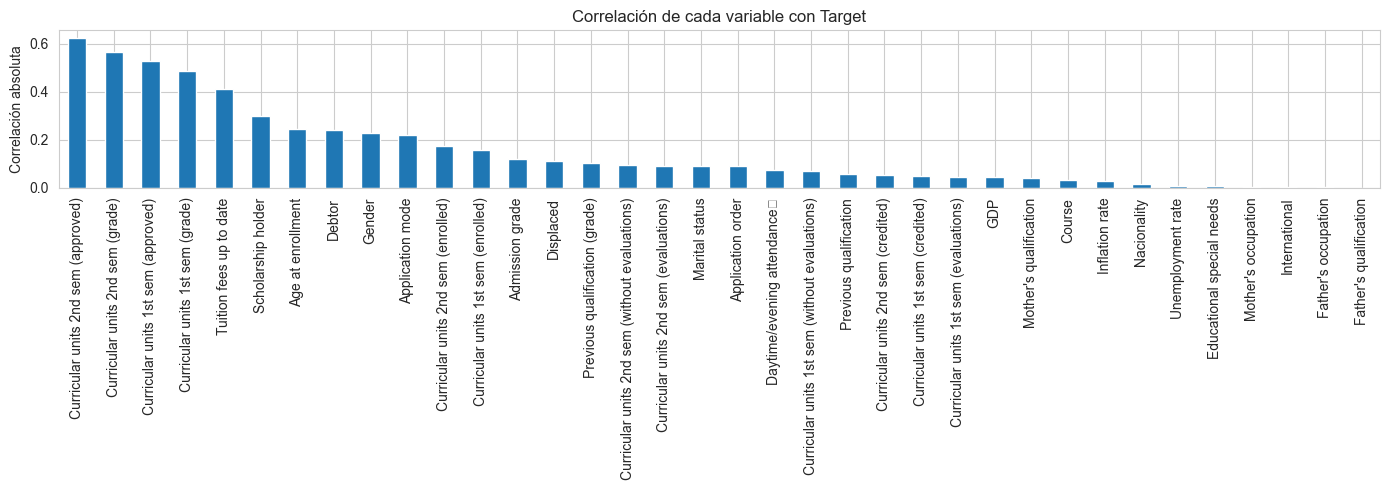

In [399]:
from sklearn.preprocessing import LabelEncoder
le_temp = LabelEncoder()
target_num = le_temp.fit_transform(df['Target'])

correlaciones_target = df.drop(columns=['Target']).corrwith(pd.Series(target_num, name='Target'))
correlaciones_target.abs().sort_values(ascending=False).plot(kind='bar', figsize=(14, 5))
plt.title('Correlación de cada variable con Target')
plt.ylabel('Correlación absoluta')
plt.tight_layout()
plt.show()

#### Interpretación

El gráfico permite identificar tres grupos claramente diferenciados 
según su correlación absoluta con la variable objetivo:

**Variables con alta correlación (>0.2):** las variables de rendimiento 
académico lideran — unidades aprobadas y calificaciones de ambos semestres 
superan 0.5. Esto confirma que lo que determina si un estudiante abandona, 
continúa o se gradúa es principalmente lo que ocurre dentro del aula, 
no su contexto previo al ingreso. Le siguen variables socioeconómicas 
como el pago de matrícula al día, la beca y las deudas, lo que sugiere 
que las dificultades económicas actúan como un factor acelerador del 
abandono cuando el rendimiento académico ya es bajo.

**Variables con correlación moderada (0.05–0.2):** variables como 
unidades matriculadas y evaluadas, modalidad de aplicación y nota de 
admisión aportan información complementaria. Su correlación moderada 
indica que tienen cierta relación con la situación final pero no son 
determinantes por sí solas — probablemente influyen en combinación 
con el rendimiento académico. Se mantienen en el dataset.

**Variables con correlación cercana a cero (<0.05):** las variables 
macroeconómicas, las unidades convalidadas y sin evaluación, 
`Nacionality`, `Educational special needs`, `International`, y las 
variables de ocupación y calificación del padre no muestran asociación 
con la situación final del estudiante. Esto sugiere que el contexto 
económico del país y el perfil familiar no determinan directamente 
si un estudiante abandona — lo que importa es cómo rinde una vez 
dentro de la institución. Estas variables se consideran candidatas 
a eliminación durante el preprocesamiento.

#### Matriz de Correlación

Se analiza la correlación entre las variables numéricas del dataset 
para identificar relaciones lineales entre ellas. Esto permite detectar 
variables redundantes que aportan información similar, lo cual es 
relevante para el preprocesamiento y la interpretación del modelo.

c:\Users\USUARIO UNA PZ\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\USUARIO UNA PZ\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


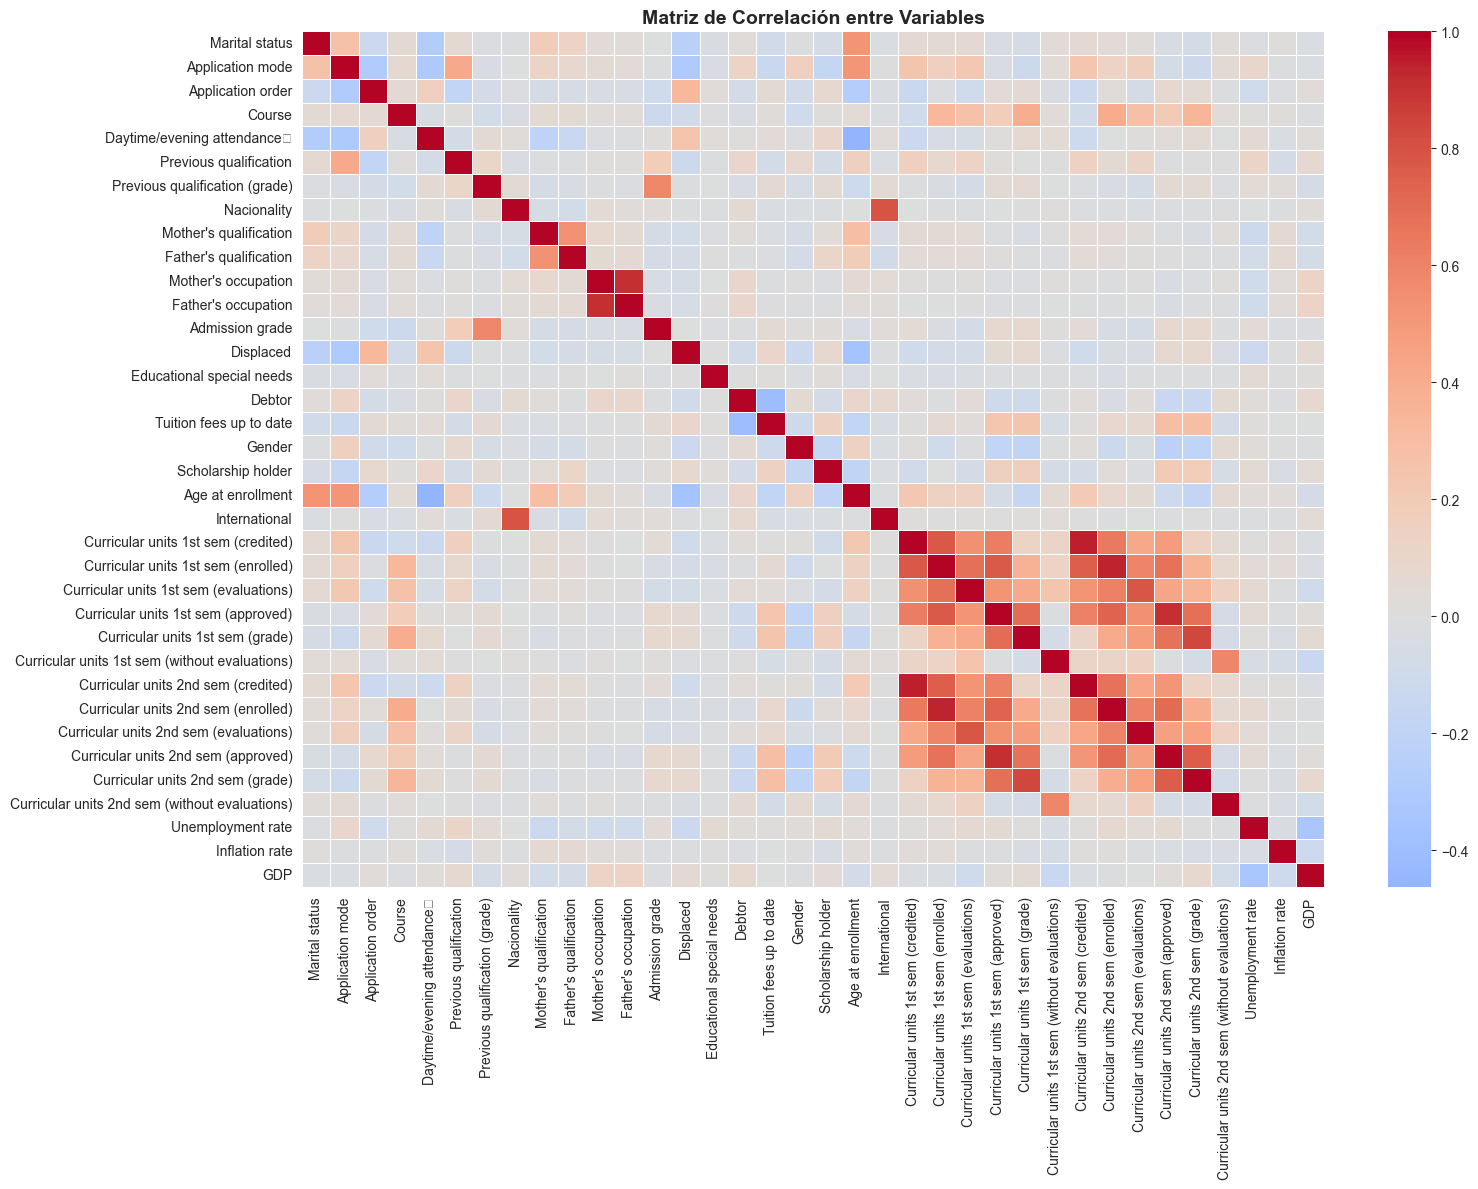

In [400]:
plt.figure(figsize=(16, 12))
correlacion = df.drop(columns=['Target']).corr()

sns.heatmap(correlacion, 
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación entre Variables', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

La matriz de correlación revela varios patrones importantes:

**Bloque académico:** las variables de rendimiento del primer y segundo 
semestre forman un bloque de alta correlación positiva (rojo oscuro) 
en la esquina inferior derecha. Esto indica que el desempeño del 
primer semestre está fuertemente relacionado con el del segundo,  estudiantes con buen rendimiento inicial tienden a mantenerlo, y 
viceversa. Esta correlación entre semestres es esperable y tiene 
sentido en el contexto académico real.

Esta alta correlación entre variables del mismo bloque se conoce como 
**multicolinealidad** fenómeno que ocurre cuando dos o más variables 
aportan información muy similar al modelo, como si estuvieran "diciendo 
lo mismo". Para Random Forest esto no representa un problema ya que el 
algoritmo maneja variables correlacionadas de forma natural. Sin embargo, 
en Regresión Logística puede dificultar la interpretación de los 
coeficientes ya que el modelo no sabe bien cómo distribuir el peso 
entre variables que transmiten información redundante, aspecto que 
se discutirá en el análisis crítico.

**Variables macroeconómicas:** Inflation rate y GDP presentan una 
correlación negativa moderada (azul) entre ellas, lo cual es consistente 
con la relación económica real entre ambos indicadores.

**Variables demográficas y socioeconómicas:** en general muestran 
correlaciones bajas entre sí y con las variables académicas, lo que 
sugiere que aportan información complementaria e independiente al modelo.

In [401]:
vars_sin_analizar = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (without evaluations)',
    'Application order'
]

for col in vars_sin_analizar:
    corr = df[col].corr(pd.Series(target_num))
    pct_cero = (df[col] == 0).mean() * 100
    print(f"{col}: correlación={corr:.4f}, % en cero={pct_cero:.1f}%")

Curricular units 1st sem (credited): correlación=0.0481, % en cero=87.0%
Curricular units 1st sem (without evaluations): correlación=-0.0687, % en cero=93.4%
Curricular units 2nd sem (credited): correlación=0.0540, % en cero=88.0%
Curricular units 2nd sem (without evaluations): correlación=-0.0940, % en cero=93.6%
Application order: correlación=0.0898, % en cero=0.0%


### 2.4 Limitaciones del Dataset

A partir del análisis exploratorio realizado, se identifican las 
siguientes limitaciones del dataset:

**Desbalance de clases:** la clase Graduate representa casi el 50% 
de los registros, lo que puede sesgar los modelos hacia predecir 
esta clase con mayor frecuencia. Se abordará mediante 
`class_weight='balanced'` durante el entrenamiento.

**Variables sin capacidad predictiva:** el análisis de correlación 
con la variable objetivo reveló que un conjunto de variables no 
aporta información relevante al modelo — entre ellas variables con 
valor dominante en más del 97% de los registros y variables 
macroeconómicas y académicas con correlación cercana a cero. 
Estas serán candidatas a eliminación en el preprocesamiento.

**Contexto geográfico específico:** los datos provienen de una 
sola institución portuguesa, lo que limita la generalización 
del modelo a otros contextos educativos con dinámicas distintas.

**Variables categóricas codificadas:** 18 variables están 
almacenadas como enteros pero representan categorías, lo que 
requiere un tratamiento especial durante el preprocesamiento 
para evitar que el modelo las interprete como valores continuos.

## 3. Preprocesamiento

El preprocesamiento es el conjunto de transformaciones que se aplican 
al dataset antes de entrenar los modelos. Su objetivo es convertir 
los datos crudos en una representación adecuada para que los 
algoritmos de aprendizaje automático puedan trabajar correctamente.

### 3.1 Eliminación de Variables sin Capacidad Predictiva

Durante el análisis exploratorio se identificaron dos grupos de variables 
que no aportan información útil para distinguir entre clases y pueden 
introducir ruido innecesario al modelo:

**Variables con baja variabilidad:** presentan un valor dominante en 
más del 97% de los registros, lo que implica que casi todos los 
estudiantes tienen el mismo valor y la variable no tiene capacidad 
discriminativa.

- **Educational special needs** — valor dominante en el 98.8% de registros
- **Nacionality** — valor dominante en el 97.5% de registros
- **International** — valor dominante en el 97.5% de registros

**Variables con correlación nula con Target (<0.05):** el análisis de 
correlación reveló que estas variables no tienen asociación relevante 
con la situación final del estudiante, confirmando que no aportan 
capacidad predictiva al modelo.

- **Inflation rate** — correlación: -0.027
- **GDP** — correlación: 0.044
- **Unemployment rate** — correlación: 0.009
- **Curricular units 1st sem (credited)** — correlación: 0.048, 87% en cero
- **Curricular units 1st sem (without evaluations)** — correlación: -0.069, 93% en cero
- **Curricular units 2nd sem (credited)** — correlación: 0.054, 88% en cero
- **Curricular units 2nd sem (without evaluations)** — correlación: -0.094, 93% en cero

In [402]:
# Eliminar variables sin capacidad predictiva identificadas en el EDA
cols_eliminar = [
    # Baja variabilidad
    'Educational special needs',
    'Nacionality',
    'International',
    # Correlación nula
    'Inflation rate',
    'GDP',
    'Unemployment rate',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (without evaluations)',
]

df_clean = df.drop(columns=cols_eliminar)

print(f"Columnas originales: {df.shape[1]}")
print(f"Columnas después de limpieza: {df_clean.shape[1]}")
print(f"Variables eliminadas: {cols_eliminar}")

Columnas originales: 37
Columnas después de limpieza: 27
Variables eliminadas: ['Educational special needs', 'Nacionality', 'International', 'Inflation rate', 'GDP', 'Unemployment rate', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (without evaluations)']


### 3.2 Separación de Features y Target

Antes de cualquier transformación se separan las variables de entrada 
(X) de la variable objetivo (y). Esta separación debe realizarse en 
este punto, después de la limpieza pero antes de dividir los datos
para que todas las operaciones posteriores trabajen únicamente sobre 
las features sin riesgo de modificar accidentalmente la variable 
que se quiere predecir.

- **X** = las 33 características restantes tras la limpieza
- **y** = la columna `Target` con las clases `Dropout`, `Enrolled` 
  y `Graduate`

In [403]:
# Separar features y variable objetivo
X = df_clean.drop(columns=['Target'])
y = df_clean['Target']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nDistribución de clases en y:")
print(y.value_counts())

Dimensiones de X: (4424, 26)
Dimensiones de y: (4424,)

Distribución de clases en y:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


### 3.3 División Entrenamiento, Validación y Prueba

Los datos se dividen en tres conjuntos antes de aplicar cualquier 
transformación. Esta decisión es fundamental para garantizar una 
evaluación honesta del modelo, si se transformaran los datos antes 
de dividir, información de los conjuntos de validación y prueba 
influiría en las transformaciones del entrenamiento, contaminando 
la evaluación. Esto se conoce como **data leakage**.

Se utiliza una proporción 70/15/15:

- **Entrenamiento (70%)** = 3,096 registros, el modelo aprende 
  los patrones a partir de estos datos.
- **Validación (15%)** = 664 registros, se usa para comparar 
  modelos, ajustar hiperparámetros y tomar decisiones durante 
  el desarrollo. Este conjunto puede verse múltiples veces.
- **Prueba (15%)** = 664 registros, se usa únicamente al final 
  para reportar el desempeño real del modelo seleccionado en 
  datos completamente no vistos. Este conjunto se toca una sola vez.

El parámetro `stratify=y` garantiza que la proporción de cada clase 
(Dropout, Enrolled, Graduate) se mantenga igual en los tres conjuntos, 
lo cual es importante dado el desbalance de clases identificado 
en el análisis exploratorio.

El parámetro `random_state=42` asegura que la división sea 
reproducible, cualquier persona que ejecute el notebook obtendrá 
exactamente los mismos conjuntos.

In [404]:
from sklearn.model_selection import train_test_split

# Primera división: 70% train, 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Segunda división: 50% de temporal = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Tamaño entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Tamaño validación:    {X_val.shape[0]} registros ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Tamaño prueba:        {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribución de clases en validación:")
print(y_val.value_counts(normalize=True).round(3))
print(f"\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True).round(3))

Tamaño entrenamiento: 3096 registros (70%)
Tamaño validación:    664 registros (15%)
Tamaño prueba:        664 registros (15%)

Distribución de clases en entrenamiento:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64

Distribución de clases en validación:
Target
Graduate    0.500
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Distribución de clases en prueba:
Target
Graduate    0.498
Dropout     0.322
Enrolled    0.179
Name: proportion, dtype: float64


### 3.4 Clasificación de Variables por Tipo

Una decisión clave del preprocesamiento es distinguir entre dos tipos 
de variables que en este dataset se presentan ambas como números enteros 
pero requieren tratamiento diferente:

**Variables numéricas continuas**: representan magnitudes reales con 
escala y orden significativo. Por ejemplo, `Admission grade` de 95.5 
es mayor que 80.0 en un sentido matemático real. Estas variables se 
escalan con `StandardScaler` para la Regresión Logística.

**Variables categóricas codificadas**: son categorías representadas 
como enteros por conveniencia, pero el número en sí no tiene significado 
matemático. Por ejemplo, `Marital status` con valores 1, 2, 3 no 
significa que el estado civil 3 sea "mayor" que el 1 son simplemente 
etiquetas distintas. Tratarlas como numéricas haría que el modelo 
interprete relaciones de orden que no existen.

In [405]:

# Variables numéricas con escala real
numeric_features = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
]

# Variables categóricas codificadas como enteros
categorical_features = [
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance\t',
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Marital status',
    'Displaced',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder'
]

print(f"Variables numéricas:    {len(numeric_features)}")
print(f"Variables categóricas:  {len(categorical_features)}")
print(f"Total:                  {len(numeric_features) + len(categorical_features)}")

Variables numéricas:    11
Variables categóricas:  15
Total:                  26


### 3.5 Construcción de Pipelines de Preprocesamiento

Un Pipeline es una secuencia encadenada de transformaciones que se 
aplican en orden sobre los datos. Su ventaja principal es que garantiza 
que el ajuste (fit) de las transformaciones ocurra únicamente sobre 
los datos de entrenamiento, y que esos mismos parámetros aprendidos 
se apliquen después sobre los datos de prueba, previniendo data leakage.

Los tres modelos seleccionados requieren transformaciones distintas:

| Transformación        | Regresión Logística | Random Forest | XGBoost       |
|-----------------------|---------------------|---------------|---------------|
| Escalado numérico     | Sí (StandardScaler) | No            | No            |
| Variables categóricas | OneHotEncoder       | OrdinalEncoder| OrdinalEncoder|

**Regresión Logística** necesita escalado porque es un modelo basado 
en optimización matemática, variables con escalas muy distintas 
hacen que el algoritmo converja lentamente o asigne pesos distorsionados. 
El OneHotEncoder convierte cada categoría en una columna binaria 
separada, evitando que el modelo interprete orden donde no existe.

**Random Forest** no necesita escalado porque los árboles de decisión 
toman decisiones por umbrales y no se ven afectados por la magnitud 
de las variables. Se usa OrdinalEncoder en lugar de OneHotEncoder 
porque es más eficiente computacionalmente para árboles y produce 
el mismo resultado práctico.

**XGBoost** comparte el mismo preprocesador que Random Forest por 
las mismas razones — al ser también un modelo basado en árboles de 
decisión, no requiere escalado y funciona igualmente bien con 
OrdinalEncoder.

In [406]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Pipeline para Regresión Logística (con escalado)
preprocessor_lr = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                         sparse_output=False), categorical_features)
])

# Pipeline para Random Forest (sin escalado)
preprocessor_rf = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                          unknown_value=-1), categorical_features)
])

print("Preprocesador Regresión Logística:")
print(preprocessor_lr)
print("\nPreprocesador Random Forest:")
print(preprocessor_rf)

Preprocesador Regresión Logística:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Previous qualification (grade)',
                                  'Admission grade', 'Age at enrollment',
                                  'Curricular units 1st sem (enrolled)',
                                  'Curricular units 1st sem (evaluations)',
                                  'Curricular units 1st sem (approved)',
                                  'Curricular units 1st sem (grade)',
                                  'Curricular units 2nd sem (enrolled)',
                                  'Curricular units 2nd sem (evaluations)',
                                  'Curricular units 2nd s...
                                  'Curricular units 2nd sem (grade)']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
          

### 3.6 Verificación del Preprocesamiento

Antes de proceder al entrenamiento se verifica que ambos pipelines 
funcionan correctamente aplicándolos sobre el conjunto de 
entrenamiento. Se comprueba que las dimensiones resultantes sean 
coherentes con las transformaciones aplicadas.

El preprocesador de Regresión Logística genera más columnas que el 
de Random Forest porque el `OneHotEncoder` expande cada variable 
categórica en múltiples columnas binarias, una por cada categoría 
posible. El `OrdinalEncoder` en cambio mantiene una sola columna 
por variable.

In [407]:
# Verificar preprocesador de Regresión Logística
X_train_lr = preprocessor_lr.fit_transform(X_train)
X_val_lr   = preprocessor_lr.transform(X_val)
X_test_lr  = preprocessor_lr.transform(X_test)

print("=== Regresión Logística ===")
print(f"Train: {X_train_lr.shape}")
print(f"Val:   {X_val_lr.shape}")
print(f"Test:  {X_test_lr.shape}")

# Verificar preprocesador de Random Forest
X_train_rf = preprocessor_rf.fit_transform(X_train)
X_val_rf   = preprocessor_rf.transform(X_val)
X_test_rf  = preprocessor_rf.transform(X_test)

print("\n=== Random Forest ===")
print(f"Train: {X_train_rf.shape}")
print(f"Val:   {X_val_rf.shape}")
print(f"Test:  {X_test_rf.shape}")

# XGBoost usa el mismo preprocesador que RF
X_train_xgb = X_train_rf.copy()
X_val_xgb   = X_val_rf.copy()
X_test_xgb  = X_test_rf.copy()

print("\n=== XGBoost (mismo preprocesador que RF) ===")
print(f"Train: {X_train_xgb.shape}")
print(f"Val:   {X_val_xgb.shape}")
print(f"Test:  {X_test_xgb.shape}")

=== Regresión Logística ===
Train: (3096, 220)
Val:   (664, 220)
Test:  (664, 220)

=== Random Forest ===
Train: (3096, 26)
Val:   (664, 26)
Test:  (664, 26)

=== XGBoost (mismo preprocesador que RF) ===
Train: (3096, 26)
Val:   (664, 26)
Test:  (664, 26)


### 4.1 Modelo 1 Regresión Logística

La Regresión Logística es un modelo lineal que aprende el peso 
o importancia de cada variable para predecir a qué clase pertenece 
un estudiante. Para cada estudiante calcula una probabilidad de 
pertenecer a cada clase Dropout, Enrolled o Graduate, y predice 
la clase con mayor probabilidad.

Para clasificación multiclase utiliza la función softmax, que 
convierte las salidas del modelo en probabilidades que suman 1. 
En términos simples: el modelo multiplica cada variable por su 
peso aprendido, suma todo, y convierte el resultado en probabilidades 
entre 0 y 1 para cada clase posible.

Se incluye como modelo base porque es interpretable, eficiente 
computacionalmente y establece un punto de referencia mínimo 
que modelos más complejos deberían superar.

Los parámetros clave utilizados son:
- class_weight='balanced' que ajusta automáticamente los pesos 
  para compensar el desbalance de clases
- max_iter=1000 es un número máximo de iteraciones para convergencia
- random_state=42 para garantiza reproducibilidad

In [408]:
from sklearn.linear_model import LogisticRegression

# Definir el modelo
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
# Entrenar
lr_model.fit(X_train_lr, y_train)
print("Modelo entrenado exitosamente.")



Modelo entrenado exitosamente.


### 4.2 Modelo 2 Random Forest

Random Forest es un algoritmo de aprendizaje en conjunto, 
que construye múltiples árboles de decisión durante el entrenamiento 
y combina sus predicciones por votación mayoritaria. Cada árbol 
se entrena sobre una muestra aleatoria del dataset y considera 
solo un subconjunto aleatorio de variables en cada división, 
lo que reduce la correlación entre árboles y mejora la generalización.

Se selecciona por tres razones principales:
- Maneja simultáneamente variables numéricas y categóricas sin 
  requerir escalado.
- Es resistente al sobreajuste gracias a la agregación de múltiples 
  árboles.
- Permite obtener la importancia relativa de cada variable, lo cual 
  es valioso para entender qué factores influyen más en el abandono 
  escolar.

In [409]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_rf, y_train)
print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


### 4.3 Modelo 3  XGBoost

XGBoost (Extreme Gradient Boosting) es un algoritmo de ensamble 
basado en árboles de decisión que construye modelos de forma 
secuencial, cada árbol nuevo intenta corregir los errores del 
anterior. A diferencia de Random Forest que construye árboles 
en paralelo e independientes, XGBoost aprende iterativamente 
minimizando una función de pérdida mediante descenso de gradiente.

En términos simples: si el modelo anterior se equivocó en predecir 
a un estudiante Dropout, el siguiente árbol prestará más atención 
a ese tipo de casos para no cometer el mismo error.

Se selecciona como tercer modelo porque su enfoque secuencial 
tiene mayor potencial para mejorar el desempeño en clases 
difíciles como Enrolled, e incorpora regularización L1 y L2 
de forma nativa para controlar el sobreajuste.

Los parámetros clave utilizados son:
- `n_estimators=100` — número de árboles en secuencia
- `max_depth=6` — profundidad máxima de cada árbol
- `learning_rate=0.1` — qué tan rápido aprende de cada árbol anterior
- `subsample=0.8` — usa el 80% de los datos por árbol para reducir overfitting
- `sample_weight` — pesos calculados por clase para compensar el desbalance
- `random_state=42` — garantiza reproducibilidad

In [410]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Pesos para compensar desbalance de clases
sample_weights = compute_sample_weight(
    class_weight='balanced', 
    y=y_train_enc
)

# Modelo baseline
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_xgb, y_train_enc, 
              sample_weight=sample_weights)
print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## 5. Evaluación Experimental

### 5.1 Evaluación Baseline

Se evalúa el desempeño inicial de los tres modelos sin ajuste de 
hiperparámetros sobre el conjunto de validación. Esto establece 
un punto de referencia para medir el impacto del ajuste posterior.

In [411]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Modelo': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision (macro)': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall (macro)': round(recall_score(y_true, y_pred, average='macro'), 4),
        'F1 (macro)': round(f1_score(y_true, y_pred, average='macro'), 4)
    }
# Predicciones baseline sobre validación
y_pred_lr = lr_model.predict(X_val_lr)
y_pred_rf = rf_model.predict(X_val_rf)
y_pred_xgb = xgb_model.predict(X_val_xgb)
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

# Tabla comparativa baseline
resultados_baseline = [
    get_metrics(y_val, y_pred_lr, 'LR Baseline'),
    get_metrics(y_val, y_pred_rf, 'RF Baseline'),
    get_metrics(y_val, y_pred_xgb_labels, 'XGBoost Baseline')
]

pd.DataFrame(resultados_baseline)

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,LR Baseline,0.7289,0.7007,0.7067,0.6943
1,RF Baseline,0.7500,0.6976,0.6537,0.6637
2,XGBoost Baseline,0.7334,0.6882,0.6881,0.6857


#### Interpretación

Los tres modelos baseline muestran un patrón común que refleja 
la dificultad intrínseca del problema — en los tres casos la 
clase Enrolled es la más difícil de predecir correctamente, 
lo que arrastra el F1 macro hacia abajo.

Regresión Logística lidera en F1 macro (0.6943) a pesar de 
tener menor Accuracy que Random Forest (0.7289 vs 0.7500). 
Esto confirma que el Accuracy es una métrica engañosa en 
datasets desbalanceados — RF tiene mayor Accuracy porque 
predice bien Graduate que es la clase mayoritaria, pero 
falla más en las clases minoritarias.

Random Forest muestra la mayor brecha entre Precision (0.6976) 
y Recall (0.6537) — indica que cuando predice correctamente 
es bastante preciso, pero deja pasar muchos casos sin detectar.

XGBoost obtiene resultados intermedios en todas las métricas, 
con un comportamiento más equilibrado entre Precision y Recall 
(0.6882 vs 0.6881).

El ajuste de hiperparámetros buscará mejorar especialmente 
el desempeño en Enrolled — la clase que más impacta el F1 macro.

### 5.2 Ajuste de Hiperparámetros

Se aplica búsqueda exhaustiva de hiperparámetros mediante GridSearchCV 
con validación cruzada estratificada de 5 folds sobre el conjunto de 
entrenamiento. El objetivo es encontrar la combinación de parámetros 
que maximice el F1 macro, métrica principal del proyecto.

Se utiliza exclusivamente el conjunto de entrenamiento para este proceso. 
El conjunto de validación se reserva para la evaluación posterior, ya que 
usarlo durante el ajuste introduciría información de datos "no vistos" en 
las decisiones de entrenamiento, contaminando la evaluación final.

La validación cruzada estratificada garantiza que en cada fold se mantenga 
la proporción original de clases (Dropout 32%, Enrolled 18%, Graduate 50%), 
lo cual es crítico dado el desbalance del dataset: sin estratificación, 
algunos folds podrían tener muy pocos ejemplos de Enrolled y producir 
estimaciones de desempeño poco confiables.

In [412]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def ajustar_modelo(modelo, param_grid, X_train, y_train, nombre):
    grid = GridSearchCV(
        modelo,
        param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    print(f"\n=== {nombre} ===")
    print(f"Mejores parámetros: {grid.best_params_}")
    print(f"Mejor F1 macro en validación cruzada: {grid.best_score_:.4f}")
    return grid

# Grids de hiperparámetros
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']
}

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8]
}

# Ajuste
grid_lr = ajustar_modelo(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid_lr, X_train_lr, y_train, 'Regresión Logística'
)

grid_rf = ajustar_modelo(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf, X_train_rf, y_train, 'Random Forest'
)

# XGBoost requiere clases numéricas — y_train_enc es y_train codificado con LabelEncoder
grid_xgb = ajustar_modelo(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    param_grid_xgb, X_train_xgb, y_train_enc, 'XGBoost'
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== Regresión Logística ===
Mejores parámetros: {'C': 0.1, 'solver': 'lbfgs'}
Mejor F1 macro en validación cruzada: 0.7117
Fitting 5 folds for each of 27 candidates, totalling 135 fits

=== Random Forest ===
Mejores parámetros: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Mejor F1 macro en validación cruzada: 0.7110
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== XGBoost ===
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Mejor F1 macro en validación cruzada: 0.7048


#### Resultado del Ajuste

- **Regresión Logística** — mejores parámetros: `C=0.1`, `solver='lbfgs'`. 
  El valor bajo de C indica que el modelo necesita regularización fuerte 
  para generalizar bien. Esto tiene sentido dado el alto número de variables 
  tras el OneHotEncoder — con muchas columnas el modelo sin regularización 
  tiende a asignar pesos grandes a variables poco relevantes, y C=0.1 
  lo penaliza para enfocarse en las señales más consistentes.
  F1 macro en validación cruzada: 0.7117.

- **Random Forest** — mejores parámetros: `max_depth=10`, 
  `min_samples_split=10`, `n_estimators=200`. Que el óptimo sea 
  `max_depth=10` y no `None` indica que los árboles sin restricción 
  de profundidad tienden a crecer hasta memorizar el dataset en lugar 
  de aprender patrones generalizables. El valor de `min_samples_split=10` 
  refuerza esto — exigir al menos 10 muestras para dividir un nodo 
  evita que el árbol cree ramas muy específicas para casos individuales 
  del entrenamiento que no se repetirán en datos nuevos.
  F1 macro en validación cruzada: 0.7110.

- **XGBoost** — mejores parámetros: `colsample_bytree=0.8`, 
  `learning_rate=0.1`, `max_depth=5`, `n_estimators=200`, `subsample=0.8`. 
  El submuestreo de columnas y filas al 80% introduce aleatoriedad en 
  cada árbol, lo que reduce la correlación entre ellos y mejora la 
  generalización. El `max_depth=5` más bajo que en iteraciones anteriores 
  indica que árboles menos profundos generalizan mejor — cuando se le 
  permite crecer demasiado, XGBoost tiende a memorizar patrones muy 
  específicos del entrenamiento que no aparecen en datos nuevos.
  F1 macro en validación cruzada: 0.7048.

Los tres modelos obtienen resultados muy similares en validación cruzada, 
con una diferencia máxima de 0.007 entre el mejor (LR, 0.7117) y el peor 
(XGBoost, 0.7048). Que tres algoritmos de naturaleza muy distinta converjan 
al mismo nivel de desempeño sugiere que el límite no está en el modelo sino 
en el problema mismo — específicamente en la dificultad estructural de 
distinguir la clase Enrolled de las otras dos, ya que estos estudiantes 
activos comparten características académicas tanto con quienes abandonan 
como con quienes se gradúan, y ningún algoritmo resuelve esa ambigüedad 
solo con ajuste de hiperparámetros.

#### Entrenamiento con Mejores Parámetros

Una vez identificada la combinación óptima de hiperparámetros para cada 
modelo, se extraen los mejores estimadores encontrados por GridSearchCV 
y se evalúan sobre el conjunto de validación — datos que ningún modelo 
vio durante el entrenamiento ni durante la búsqueda de hiperparámetros.

Esta evaluación sobre validación es la primera medida real de qué tan 
bien generaliza cada modelo con su configuración óptima, y será la base 
para la comparación formal y la selección del modelo final.

In [422]:
# Obtener mejores modelos
lr_tuned = grid_lr.best_estimator_
rf_tuned = grid_rf.best_estimator_
xgb_tuned = grid_xgb.best_estimator_

# Predecir sobre validación
y_pred_lr_tuned = lr_tuned.predict(X_val_lr)
y_pred_rf_tuned = rf_tuned.predict(X_val_rf)
y_pred_xgb_tuned = xgb_tuned.predict(X_val_xgb)
y_pred_xgb_tuned_labels = le.inverse_transform(y_pred_xgb_tuned)

# Tabla comparativa
resultados_tuned = [
    get_metrics(y_val, y_pred_lr_tuned, 'LR Tuned'),
    get_metrics(y_val, y_pred_rf_tuned, 'RF Tuned'),
    get_metrics(y_val, y_pred_xgb_tuned_labels, 'XGBoost Tuned')
]

df_tuned = pd.DataFrame(resultados_tuned)
df_tuned

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,LR Tuned,0.7364,0.7065,0.7107,0.6990
1,RF Tuned,0.7289,0.6896,0.6877,0.6839
2,XGBoost Tuned,0.7515,0.6989,0.6803,0.6874


#### Interpretación

Los tres modelos tuned muestran un desempeño similar, con diferencias 
de F1 macro menores a 0.02. Sin embargo hay patrones relevantes que 
orientan la selección del modelo final.

**Regresión Logística** lidera en F1 macro (0.6990), lo que es 
destacable considerando que es el modelo más simple de los tres. 
Esto confirma que las variables académicas tienen una relación 
relativamente directa con la variable objetivo — la señal principal 
es suficientemente clara como para que un modelo lineal la capture 
sin necesidad de mayor complejidad.

**XGBoost** queda en segundo lugar con F1 macro de 0.6874 y el mayor 
Accuracy (0.7515). Sin embargo, liderar en Accuracy no es necesariamente 
positivo en un dataset desbalanceado — puede indicar que el modelo 
predice bien la clase mayoritaria Graduate pero falla más en las 
clases minoritarias, lo que se analizará formalmente en la verificación 
de overfitting.

**Random Forest** presenta el resultado más llamativo: obtuvo un F1 
macro en validación cruzada de 0.7110, prácticamente igual al de LR, 
pero el peor F1 sobre el conjunto de validación (0.6839). Esta caída 
sugiere que a pesar del ajuste de hiperparámetros el modelo sigue 
tendiendo a sobreajustarse, memorizando patrones específicos del 
entrenamiento que no generalizan igual de bien a datos nuevos. 
Esto se analizará formalmente en la sección de verificación de 
overfitting.

### 5.3 Verificación de Overfitting

Se compara el F1 macro de cada modelo tuned sobre los datos de 
entrenamiento versus el conjunto de validación. Una diferencia 
grande entre ambos indica que el modelo memorizó los datos de 
entrenamiento en lugar de aprender patrones generalizables — 
fenómeno conocido como sobreajuste u overfitting.

In [414]:
from sklearn.metrics import f1_score

# Predicciones sobre entrenamiento
y_pred_train_lr = lr_tuned.predict(X_train_lr)
y_pred_train_rf = rf_tuned.predict(X_train_rf)
y_pred_train_xgb = xgb_tuned.predict(X_train_xgb)
y_pred_train_xgb_labels = le.inverse_transform(y_pred_train_xgb)

# Tabla comparativa train vs validación
modelos_overfitting = [
    ('LR Tuned',      y_train, y_pred_train_lr,         y_val, y_pred_lr_tuned),
    ('RF Tuned',      y_train, y_pred_train_rf,         y_val, y_pred_rf_tuned),
    ('XGBoost Tuned', y_train, y_pred_train_xgb_labels, y_val, y_pred_xgb_tuned_labels)
]

print(f"{'Modelo':<15} {'F1 Train':>10} {'F1 Val':>10} {'Diferencia':>12} {'Estado':>15}")
print("-" * 65)
for nombre, y_tr, y_pr_tr, y_v, y_pr_v in modelos_overfitting:
    f1_train = f1_score(y_tr, y_pr_tr, average='macro')
    f1_val   = f1_score(y_v, y_pr_v, average='macro')
    diff     = f1_train - f1_val
    estado   = 'Severo' if diff > 0.15 else 'Moderado' if diff > 0.05 else 'Aceptable'
    print(f"{nombre:<15} {f1_train:>10.4f} {f1_val:>10.4f} {diff:>12.4f} {estado:>15}")

Modelo            F1 Train     F1 Val   Diferencia          Estado
-----------------------------------------------------------------
LR Tuned            0.7427     0.6990       0.0437       Aceptable
RF Tuned            0.8460     0.6839       0.1620          Severo
XGBoost Tuned       0.9768     0.6874       0.2894          Severo


#### Interpretación

Los resultados revelan diferencias críticas entre los tres modelos 
que no eran visibles solo con las métricas de validación:

**Regresión Logística** presenta una diferencia de 0.0437, clasificada 
como aceptable — la más baja de todo el proceso. El modelo aprendió 
patrones genuinamente generalizables sin memorizar los datos de 
entrenamiento. Su regularización fuerte (C=0.1) cumplió exactamente 
su propósito: penalizar pesos grandes en variables poco relevantes 
y enfocarse en las señales más consistentes del dataset.

**Random Forest** presenta overfitting severo con una diferencia de 
0.1620. A pesar de haber limitado la profundidad a 10 niveles y 
exigido mínimo 10 muestras por división durante el tuning, el modelo 
sigue sobreajustándose. Esto explica la caída entre su F1 en validación 
cruzada (0.7110) y su F1 real en validación (0.6839) — dentro del 
entrenamiento funciona bien pero no generaliza igual a datos nuevos.

**XGBoost** presenta el overfitting más severo con una diferencia de 
0.2894 y un F1 de 0.9768 en entrenamiento — prácticamente memorizó 
el dataset. Esto significa que el modelo no está aprendiendo el 
problema sino los datos específicos con los que entrenó, lo que lo 
hace poco confiable para predecir casos nuevos a pesar de obtener 
un F1 de validación de 0.6874.

Este hallazgo reposiciona completamente el ranking de la sección 
anterior. El único modelo que aprendió de forma genuinamente 
generalizable es **Regresión Logística**, lo que lo convierte en 
el candidato más sólido para la selección final — su menor 
overfitting es una garantía de que su desempeño en datos nuevos 
será consistente con lo observado en validación.

### 5.4 Comparación Formal — Modelos Tuned

Con los modelos ajustados y verificado su comportamiento frente 
al overfitting, se procede a un análisis visual detallado del 
desempeño de cada uno. Las matrices de confusión permiten ir 
más allá de las métricas agregadas e identificar exactamente 
qué clases confunde cada modelo y con qué frecuencia — 
información que una tabla de métricas no captura.

#### Matrices de Confusión

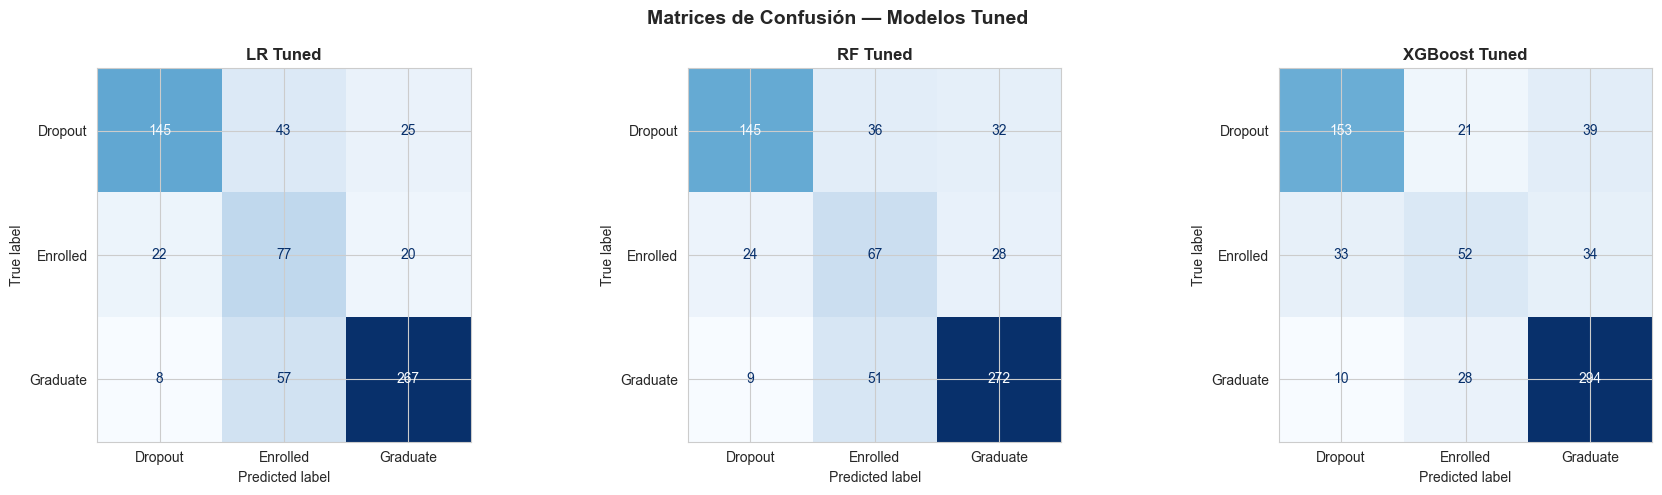

In [415]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_cm = [
    ('LR Tuned',      y_val, y_pred_lr_tuned,         lr_tuned.classes_),
    ('RF Tuned',      y_val, y_pred_rf_tuned,         rf_tuned.classes_),
    ('XGBoost Tuned', y_val, y_pred_xgb_tuned_labels, lr_tuned.classes_)
]

for ax, (nombre, y_true, y_pred, clases) in zip(axes, modelos_cm):
    cm = confusion_matrix(y_true, y_pred, labels=clases)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre, fontsize=12, fontweight='bold')

plt.suptitle('Matrices de Confusión — Modelos Tuned', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

Los tres modelos comparten la misma debilidad estructural: 
**Enrolled es la clase más difícil** en todos los casos, lo cual 
es consistente con ser la clase minoritaria del dataset y con que 
los estudiantes activos comparten características académicas tanto 
con quienes abandonan como con quienes se gradúan.

**Dropout** — XGBoost identifica más correctamente a los estudiantes 
en riesgo (153/213) comparado con LR (145/213) y RF (145/213). Sin 
embargo XGBoost también comete el error más grave institucionalmente: 
clasifica 39 estudiantes que abandonarán como Graduate, lo que 
significa que el sistema los consideraría seguros cuando en realidad 
están en riesgo de dejar la carrera. Este tipo de error tiene 
consecuencias directas — una institución que confía en esa predicción 
no intervendrá a tiempo.

**Enrolled** — LR es el modelo que mejor detecta esta clase (77/119), 
superando a RF (67/119) y XGBoost (52/119). Que un modelo lineal 
supere a dos modelos de árboles en la clase más difícil refuerza 
lo observado en la verificación de overfitting — RF y XGBoost 
memorizan patrones del entrenamiento que no generalizan bien a 
casos intermedios como los estudiantes activos, cuya trayectoria 
aún no ha concluido.

**Graduate** — XGBoost lidera con 294/331 correctos, seguido de 
RF (272/331) y LR (267/331). Esta es la clase más fácil para los 
tres modelos dado que los graduados tienen las señales académicas 
más claras y consistentes — altas calificaciones y materias 
aprobadas de forma sostenida en ambos semestres.

El patrón general confirma que ningún modelo es superior en todas 
las clases — XGBoost gana en Dropout y Graduate pero falla 
considerablemente en Enrolled, mientras que LR tiene el mejor 
balance entre las tres clases, lo cual es coherente con su menor 
overfitting y lo posiciona como el candidato más confiable para 
un sistema de detección temprana.

#### Curvas ROC

La curva ROC (Receiver Operating Characteristic) evalúa la 
capacidad discriminativa de cada modelo independientemente 
del umbral de decisión. El área bajo la curva (AUC) resume 
ese desempeño en un solo número — cuanto más cercano a 1.0, 
mayor es la capacidad del modelo para separar una clase del 
resto.

Para clasificación multiclase se utiliza el enfoque One vs Rest 
(OvR): por cada clase se calcula una curva ROC tratándola como 
positiva y las demás como negativas. Esto permite identificar 
en cuáles clases cada modelo tiene mayor o menor capacidad 
discriminativa, más allá de lo que muestra la matriz de confusión.

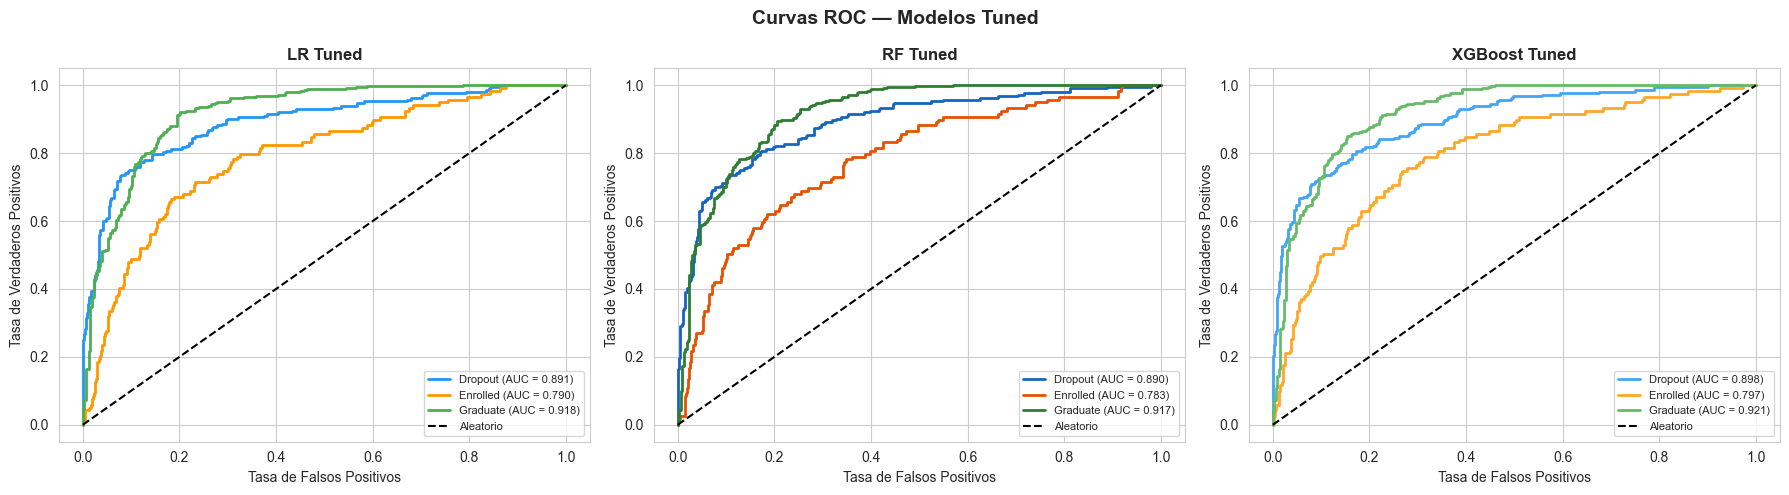

In [416]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar clases para ROC multiclase
clases = lr_tuned.classes_
y_val_bin = label_binarize(y_val, classes=clases)

# Probabilidades de cada modelo tuned
y_prob_lr  = lr_tuned.predict_proba(X_val_lr)
y_prob_rf  = rf_tuned.predict_proba(X_val_rf)
y_prob_xgb = xgb_tuned.predict_proba(X_val_xgb)

# Colores y modelos
modelos_roc = [
    ('LR Tuned',      y_prob_lr,  ['#2196F3', '#FF9800', '#4CAF50']),
    ('RF Tuned',      y_prob_rf,  ['#1565C0', '#E65100', '#2E7D32']),
    ('XGBoost Tuned', y_prob_xgb, ['#42A5F5', '#FFA726', '#66BB6A'])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, y_prob, colores) in zip(axes, modelos_roc):
    for i, (cls, color) in enumerate(zip(clases, colores)):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls} (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatorio')
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Curvas ROC — Modelos Tuned', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

La curva ROC mide la capacidad de cada modelo para distinguir 
entre clases independientemente del umbral de decisión. Un AUC 
cercano a 1.0 indica mayor capacidad discriminativa.

| Clase    | LR Tuned | RF Tuned | XGBoost Tuned |
|----------|----------|----------|---------------|
| Dropout  | 0.891    | 0.890    | 0.898         |
| Enrolled | 0.790    | 0.783    | 0.797         |
| Graduate | 0.918    | 0.917    | 0.921         |

Los tres modelos muestran una capacidad discriminativa real y 
consistentemente superior al clasificador aleatorio (AUC = 0.5) 
en todas las clases, lo que confirma que los tres aprendieron 
patrones útiles del dataset.

**Dropout** — XGBoost lidera marginalmente (0.898) seguido de LR 
(0.891) y RF (0.890). Las diferencias son mínimas, lo que indica 
que los tres modelos tienen capacidad similar para distinguir 
estudiantes en riesgo del resto — la señal del abandono es 
suficientemente clara como para que cualquiera de los tres la capture.

**Enrolled** — es consistentemente la clase con menor AUC en los 
tres modelos, confirmando lo observado en las matrices de confusión. 
XGBoost obtiene el mejor AUC (0.797) y RF el peor (0.783). Sin 
embargo, que todos superen 0.78 indica que los modelos sí tienen 
capacidad para identificar estudiantes activos — el problema no 
es que no puedan distinguirlos sino que cuando deben tomar una 
decisión de clase concreta, el umbral por defecto no es el óptimo 
para esta clase minoritaria, que comparte características con 
las otras dos.

**Graduate** — XGBoost obtiene el mejor AUC (0.921), seguido de 
LR (0.918) y RF (0.917). Las diferencias son prácticamente 
insignificantes, lo que confirma que Graduate tiene señales 
académicas tan claras y consistentes que cualquiera de los tres 
modelos las captura con igual efectividad.

El patrón general es que las diferencias entre modelos en AUC 
son muy pequeñas — máximo 0.014 entre el mejor y el peor en 
cualquier clase. Esto refuerza que el factor diferenciador entre 
ellos no es la capacidad discriminativa sino el overfitting — 
todos tienen una capacidad similar para separar las clases, pero 
solo LR lo hace de forma generalizable a datos nuevos.

### 5.6 Selección del Mejor Modelo

Con toda la evidencia recopilada a lo largo de la evaluación 
experimental, se procede a seleccionar el modelo que mejor 
cumple los requisitos del problema. La decisión no se basa 
en una sola métrica sino en un análisis integral que considera 
desempeño, confiabilidad y capacidad de generalización.

| Criterio                  | LR Tuned    | RF Tuned  | XGBoost Tuned |
|---------------------------|-------------|-----------|---------------|
| F1 macro (validación)     | **0.6990**  | 0.6839    | 0.6874        |
| F1 macro (entrenamiento)  | 0.7427      | 0.8460    | 0.9768        |
| Diferencia (overfitting)  | **0.0437**  | 0.1620    | 0.2894        |
| Enrolled detectados       | **77/119**  | 67/119    | 52/119        |
| AUC promedio              | **0.866**   | 0.863     | 0.872         |
| Generalización            | **Alta**    | Baja      | Muy baja      |

**Modelo seleccionado: Regresión Logística Tuned**

La decisión se fundamenta en tres razones:

**1. Único modelo sin overfitting significativo:** con una diferencia 
de apenas 0.0437 entre entrenamiento y validación, LR es el único 
modelo que aprendió patrones genuinamente generalizables. RF y XGBoost 
memorizaron el dataset de entrenamiento — un F1 de 0.9768 en 
entrenamiento no es un logro sino una señal de alarma que indica 
que el modelo aprendió los datos específicos y no el problema.

**2. Mejor detección de la clase crítica:** LR detecta correctamente 
77 de 119 estudiantes Enrolled, superando a RF (67/119) y XGBoost 
(52/119). Enrolled es la clase más difícil y más importante 
institucionalmente — son estudiantes activos cuya trayectoria aún 
puede ser influenciada por una intervención a tiempo. Un modelo 
que los clasifica incorrectamente como Dropout o Graduate pierde 
precisamente la oportunidad de intervenir cuando aún es posible.

**3. Coherencia metodológica:** a diferencia de iteraciones anteriores, 
en esta versión LR también lidera en F1 macro de validación (0.6990), 
lo que elimina cualquier ambigüedad en la selección. Los tres criterios 
— menor overfitting, mejor detección de Enrolled y mejor F1 macro — 
apuntan al mismo modelo, lo que hace la decisión sólida y consistente.

### 5.7 Evaluación Detallada del Ganador

Seleccionada la Regresión Logística Tuned como modelo final, se 
analiza en profundidad su comportamiento específico en la clase 
más problemática: Enrolled. Con un F1 de 0.63 esta clase concentra 
la mayoría de los errores del modelo y entender por qué es clave 
para conocer las limitaciones reales del sistema antes de 
implementarlo institucionalmente.


### Análisis de Errores Críticos

Las métricas agregadas y las matrices de confusión muestran el 
desempeño general del modelo, pero no todos los errores tienen 
el mismo impacto institucional. El error más grave en este problema 
es clasificar un estudiante que va a abandonar como Graduate — 
el sistema lo consideraría seguro cuando en realidad está en riesgo, 
perdiendo la oportunidad de intervenir a tiempo.

Se analiza si existe un perfil académico que explique por qué el 
modelo comete este error específico, comparando los estudiantes 
Dropout detectados correctamente contra los clasificados como Graduate.

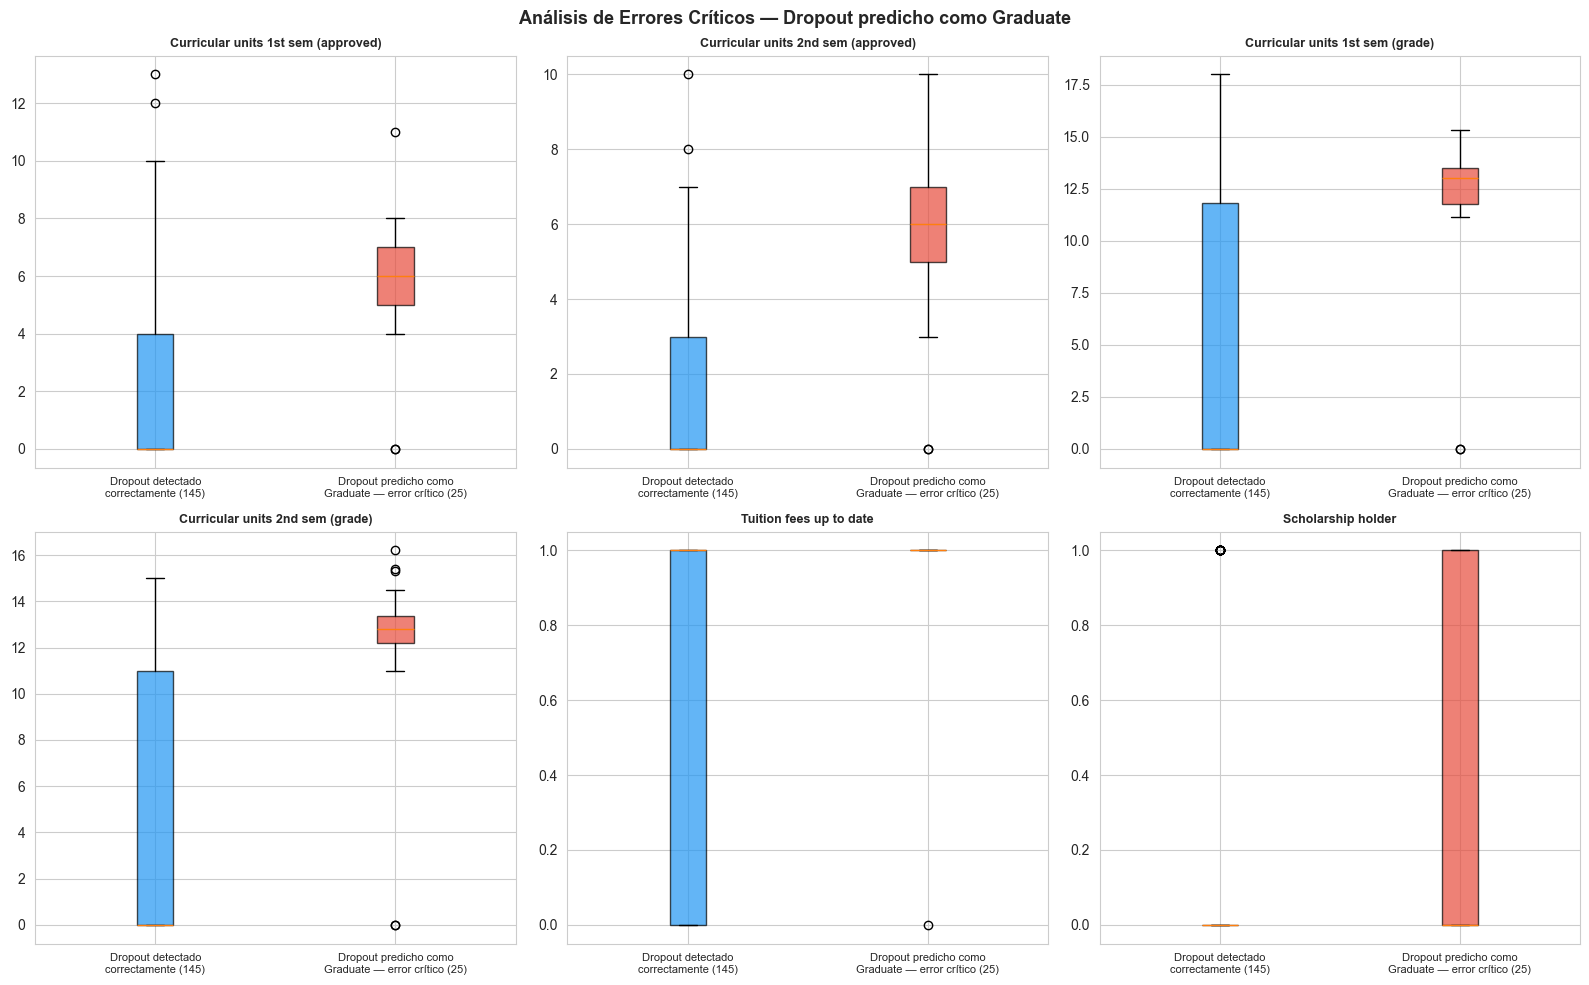

In [427]:
cols_comparar = [
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Scholarship holder'
]

df_val = X_val.copy()
df_val['Real'] = y_val.values
df_val['Predicho'] = y_pred_lr_tuned

correctos_dropout = df_val[
    (df_val['Real'] == 'Dropout') & 
    (df_val['Predicho'] == 'Dropout')
]

criticos = df_val[
    (df_val['Real'] == 'Dropout') & 
    (df_val['Predicho'] == 'Graduate')
]

n_correctos = len(correctos_dropout)
n_criticos = len(criticos)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

grupos = {
    f'Dropout detectado\ncorrectamente ({n_correctos})': correctos_dropout[cols_comparar],
    f'Dropout predicho como\nGraduate — error crítico ({n_criticos})': criticos[cols_comparar]
}

colores = ['#2196F3', '#e74c3c']

for i, col in enumerate(cols_comparar):
    datos = [grupo[col].values for grupo in grupos.values()]
    bp = axes[i].boxplot(datos, tick_labels=grupos.keys(), patch_artist=True)
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=8)

plt.suptitle('Análisis de Errores Críticos — Dropout predicho como Graduate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

El análisis revela que los errores críticos no son aleatorios — 
los estudiantes Dropout clasificados incorrectamente como Graduate 
presentan un perfil académico notablemente distinto al de los 
Dropout detectados correctamente.

**Materias aprobadas y calificaciones:** los estudiantes mal 
clasificados tienen medianas de materias aprobadas entre 5 y 6 
en ambos semestres, con calificaciones alrededor de 12-13. En 
contraste, los Dropout correctamente detectados tienen medianas 
cercanas a 0 — la señal más clara del abandono. Estos estudiantes 
rinden académicamente como un graduado típico, por lo que el 
modelo no tiene evidencia en sus notas para alertar sobre su riesgo.

**Pago de matrícula y beca:** prácticamente la totalidad de los 
mal clasificados está al día con el pago de matrícula y tiene beca. 
Son estudiantes económicamente respaldados, lo que elimina otra 
de las señales típicas de riesgo que el modelo utiliza.

Esto no es una falla del modelo sino una limitación inherente al 
problema: existen estudiantes que abandonan por razones que el 
dataset no registra — factores personales, familiares o 
motivacionales que no se reflejan en calificaciones ni en variables 
socioeconómicas. Ningún modelo puede predecir lo que los datos 
no contienen.

#### Análisis de Errores — Clase Enrolled

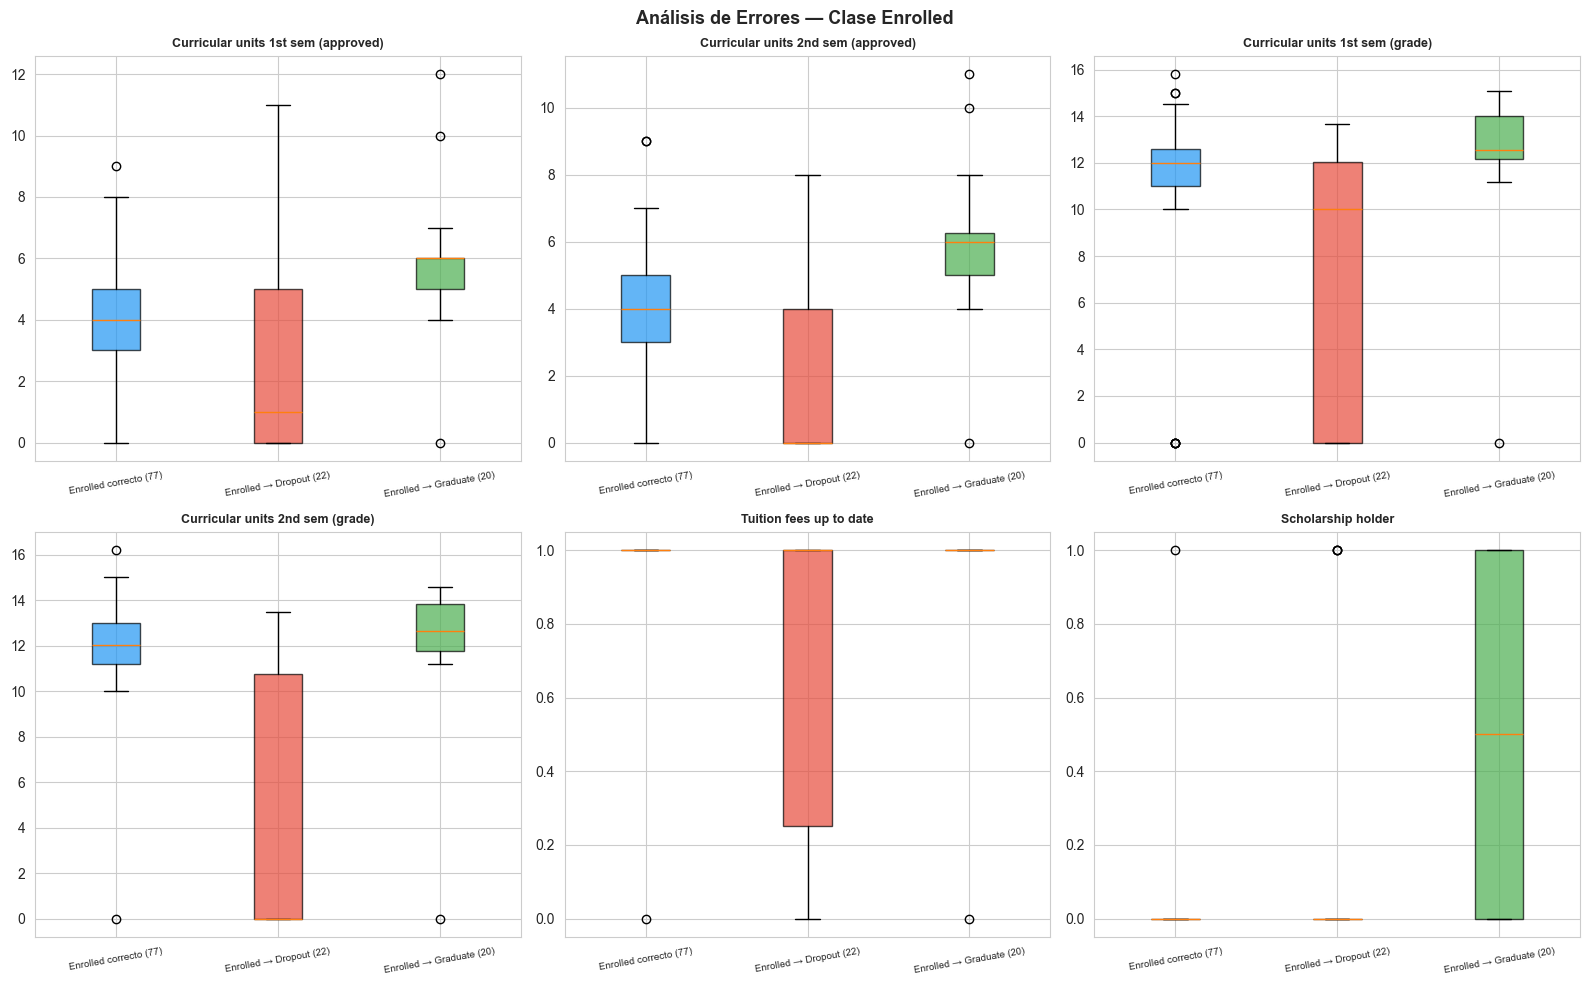

In [428]:
# Filtrar Enrolled mal clasificados
df_enrolled = X_val.copy()
df_enrolled['Real'] = y_val.values
df_enrolled['Predicho'] = y_pred_lr_tuned

enrolled_todos = df_enrolled[df_enrolled['Real'] == 'Enrolled']
enrolled_correctos = enrolled_todos[enrolled_todos['Real'] == enrolled_todos['Predicho']]
enrolled_dropout = enrolled_todos[enrolled_todos['Predicho'] == 'Dropout']
enrolled_graduate = enrolled_todos[enrolled_todos['Predicho'] == 'Graduate']

cols_comparar = [
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Scholarship holder'
]

n_correctos = len(enrolled_correctos)
n_dropout = len(enrolled_dropout)
n_graduate = len(enrolled_graduate)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

grupos = {
    f'Enrolled correcto ({n_correctos})': enrolled_correctos[cols_comparar],
    f'Enrolled → Dropout ({n_dropout})': enrolled_dropout[cols_comparar],
    f'Enrolled → Graduate ({n_graduate})': enrolled_graduate[cols_comparar]
}

colores = ['#2196F3', '#e74c3c', '#4CAF50']

for i, col in enumerate(cols_comparar):
    datos = [grupo[col].values for grupo in grupos.values()]
    bp = axes[i].boxplot(datos, tick_labels=grupos.keys(), patch_artist=True)
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=7, rotation=10)

plt.suptitle('Análisis de Errores — Clase Enrolled',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

El análisis revela que los errores en Enrolled no son aleatorios 
— cada tipo de error tiene un perfil académico distinto que explica 
por qué el modelo los confunde con clases diferentes.

**Enrolled confundido con Dropout (22 casos):** estos estudiantes 
presentan una variabilidad extrema en todas las variables académicas, 
con cajas muy amplias que van desde 0 hasta valores altos. Esto 
indica un rendimiento muy inconsistente — algunos semestres aprueban 
varias materias y otros ninguna, exactamente el mismo patrón que 
exhiben los estudiantes que abandonan. El modelo los clasifica como 
Dropout porque su comportamiento académico irregular es 
indistinguible del de alguien que está dejando la carrera.

**Enrolled confundido con Graduate (20 casos):** en contraste, 
estos estudiantes tienen un perfil académico sólido y consistente 
— calificaciones entre 12 y 13, materias aprobadas concentradas 
entre 5 y 6, y prácticamente todos tienen beca. Son estudiantes 
que rinden bien y están económicamente respaldados, exactamente 
como un graduado típico. El modelo los clasifica como Graduate 
porque no hay ninguna señal en los datos que indique que no van 
a terminar.

**La raíz del problema:** Enrolled es una clase estructuralmente 
ambigua. No tiene un perfil propio definido — contiene estudiantes 
que se parecen a Dropout y estudiantes que se parecen a Graduate, 
pero que por razones no registradas en el dataset aún no han 
concluido su trayectoria. Esto no es una falla del modelo sino 
una limitación inherente al problema: predecir el estado futuro 
de estudiantes cuya historia aún no ha terminado.

#### Evaluación Final sobre Conjunto de Prueba

Una vez seleccionado y analizado el modelo final, se evalúa 
por primera y única vez sobre el conjunto de prueba — datos 
que no participaron en ninguna etapa del desarrollo, ni en 
el entrenamiento, ni en el ajuste de hiperparámetros, ni en 
la selección del modelo. Este resultado representa el 
desempeño real esperado del sistema ante datos completamente 
nuevos.

In [429]:
# Evaluación final sobre conjunto de prueba
y_pred_test_lr = lr_tuned.predict(X_test_lr)

print("=== Evaluación Final — Regresión Logística Tuned ===")
print("Conjunto de prueba (datos nunca vistos)\n")
print(classification_report(y_test, y_pred_test_lr))
print(f"F1 macro: {f1_score(y_test, y_pred_test_lr, average='macro'):.4f}")

=== Evaluación Final — Regresión Logística Tuned ===
Conjunto de prueba (datos nunca vistos)

              precision    recall  f1-score   support

     Dropout       0.87      0.71      0.78       214
    Enrolled       0.46      0.70      0.56       119
    Graduate       0.88      0.82      0.85       331

    accuracy                           0.76       664
   macro avg       0.74      0.74      0.73       664
weighted avg       0.80      0.76      0.77       664

F1 macro: 0.7274


#### Interpretación

El modelo alcanza un F1 macro de 0.7274 sobre datos completamente 
nuevos, consistente con el obtenido en validación (0.6990), lo que 
confirma que el modelo generaliza bien y que su comportamiento es 
estable ante datos que nunca había visto durante ninguna etapa del 
desarrollo.

**Dropout (F1: 0.78)** — la precisión de 0.87 indica que cuando 
el modelo alerta sobre un estudiante en riesgo, tiene alta 
probabilidad de estar en lo correcto. Esto es crítico para que 
la institución confíe en el sistema — una alerta falsa frecuente 
haría que el personal ignorara las predicciones.

**Enrolled (F1: 0.56)** — sigue siendo la clase más difícil, 
consistente con todo el análisis previo. El recall de 0.70 indica 
que el modelo detecta 7 de cada 10 estudiantes activos, un resultado 
aceptable considerando la ambigüedad estructural demostrada — son 
estudiantes cuya trayectoria aún no ha concluido y que comparten 
características con las otras dos clases.

**Graduate (F1: 0.85)** — clase mejor predicha, el modelo la 
identifica con alta confianza tanto en precisión como en recall. 
Esto es esperable dado que los graduados tienen las señales 
académicas más claras y consistentes del dataset.

El resultado sobre prueba valida la decisión de seleccionar 
Regresión Logística — un modelo simple, interpretable y sin 
overfitting significativo que mantiene su desempeño de forma 
consistente ante datos completamente nuevos.

#### Exportación del Modelo Final

Con la evaluación completada, se exportan el modelo y su 
preprocesador para su uso en el sistema interactivo. Se guardan 
ambos componentes juntos porque el preprocesador es parte 
indispensable del pipeline — sin él, el modelo no puede recibir 
datos crudos nuevos correctamente.

In [430]:
import joblib
import os

# Crear carpeta si no existe
os.makedirs('../model', exist_ok=True)

# Guardar modelo final y preprocesador
joblib.dump(lr_tuned, '../model/best_model.pkl')
joblib.dump(preprocessor_lr, '../model/preprocessor.pkl')

print("Modelo guardado exitosamente.")

Modelo guardado exitosamente.


## 6. Análisis Crítico

### 6.1 Limitaciones del Modelo

El modelo desarrollado presenta limitaciones que deben considerarse 
antes de cualquier implementación institucional.

**Ambigüedad estructural de Enrolled:** la clase con mayor dificultad 
de predicción no es un problema del modelo sino del problema mismo. 
Los estudiantes activos comparten características académicas tanto 
con quienes abandonan como con quienes se gradúan, y su situación 
final depende de factores que aún no han ocurrido al momento de la 
predicción. Ningún algoritmo puede resolver esta ambigüedad con los 
datos disponibles.

**Factores no registrados:** el análisis de errores críticos demostró 
que existen estudiantes que abandonan a pesar de tener buen rendimiento 
académico y estabilidad económica. Estos casos corresponden a razones 
personales, familiares o motivacionales que el dataset no registra — 
y que ningún modelo puede predecir sin esa información.

**Contexto geográfico específico:** el dataset proviene de una sola 
institución de educación superior portuguesa. Los patrones aprendidos 
reflejan las dinámicas académicas, económicas y culturales de ese 
contexto específico, lo que limita la capacidad de generalización 
del modelo a instituciones de otros países o con perfiles estudiantiles 
distintos.

### 6.2 Riesgo de Sobreajuste

La verificación de overfitting reveló diferencias críticas entre los 
tres modelos evaluados. Random Forest presentó una diferencia de 0.1620 
entre su F1 en entrenamiento y validación, clasificada como severa. 
XGBoost fue el caso más extremo — alcanzó un F1 de 0.9768 en 
entrenamiento, lo que indica que memorizó el dataset en lugar de 
aprender patrones generalizables.

Este resultado fue contrario a las expectativas iniciales. XGBoost 
fue incluido precisamente por su reputación como uno de los algoritmos 
más potentes para problemas con desbalance de clases, esperando que 
su enfoque secuencial y su regularización nativa produjeran mejores 
métricas que los otros dos modelos. Sin embargo, en este problema 
específico su tendencia al sobreajuste superó sus ventajas — el modelo 
aprendió los datos de entrenamiento con tanta precisión que perdió 
capacidad de generalizar a casos nuevos. Esto demuestra que la 
elección del modelo debe basarse en evidencia empírica sobre el 
problema concreto y no en suposiciones sobre el comportamiento 
esperado de un algoritmo.

Regresión Logística, con una diferencia de apenas 0.0437, fue el 
único modelo que aprendió patrones genuinamente generalizables — 
resultado que se confirma con su desempeño consistente sobre el 
conjunto de prueba.

### 6.3 Posibles Sesgos en los Datos

**Sesgo institucional:** al provenir de una única institución, el 
dataset puede sobre-representar patrones específicos de ese contexto 
y sub-representar perfiles estudiantiles distintos. Un modelo 
entrenado con estos datos podría tomar decisiones incorrectas sobre 
estudiantes con características no representadas en los datos de 
entrenamiento.

**Sesgo de clase mayoritaria:** la clase Graduate representa el 49.9% 
de los registros. Aunque se aplicó class_weight='balanced' para 
compensar este desbalance, el modelo sigue teniendo más ejemplos 
de graduados para aprender, lo que puede favorecer sutilmente 
predicciones hacia esa clase.

**Sesgo socioeconómico:** variables como el pago de matrícula al día, 
las deudas y la beca son predictores relevantes del abandono. Esto 
refleja una realidad — las dificultades económicas están asociadas 
con el abandono — pero también implica que el modelo aprende 
patrones de desigualdad estructural existentes en la sociedad. 
Un estudiante en situación económica difícil podría ser marcado 
como en riesgo simplemente por su contexto, independientemente 
de su motivación o capacidad académica real.

### 6.4 Escalabilidad

El modelo de Regresión Logística es computacionalmente eficiente 
y escala bien con volúmenes mayores de datos — su tiempo de 
entrenamiento crece de forma lineal con el número de registros, 
lo que lo hace viable para datasets más grandes.

Sin embargo, la escalabilidad del sistema va más allá del modelo. 
Para implementarse en una institución real se requeriría:

- **Actualización periódica:** el modelo fue entrenado con datos 
  de un período específico. Las condiciones académicas e institucionales 
  cambian con el tiempo, por lo que el modelo debería reentrenarse 
  regularmente con datos recientes para mantener su capacidad predictiva.

- **Adaptación a nuevos contextos:** aplicar el modelo a una institución 
  distinta requeriría reentrenarlo con datos propios de esa institución, 
  ya que los patrones aprendidos son específicos del contexto portugués.

- **Infraestructura de datos:** la efectividad del sistema depende de 
  que la institución registre las mismas variables del dataset de forma 
  consistente y actualizada.

### 6.5 Consideraciones Éticas

El uso de inteligencia artificial para predecir la situación académica 
de estudiantes plantea consideraciones éticas que deben abordarse 
antes de cualquier implementación.

**Riesgo de estigmatización:** una predicción de Dropout no significa 
que el estudiante vaya a abandonar — es una probabilidad basada en 
patrones históricos. Si esta predicción se comunica de forma incorrecta 
o se usa para tomar decisiones automáticas sobre el estudiante, puede 
generar etiquetas injustas que afecten su autoestima, su relación con 
la institución o las oportunidades de apoyo que recibe.

**El modelo como herramienta de apoyo, no de decisión:** las 
predicciones del sistema deben usarse exclusivamente para orientar 
intervenciones de apoyo — tutoría, orientación, ayuda económica — 
y nunca para tomar decisiones automáticas sobre admisión, becas o 
permanencia del estudiante. La decisión final siempre debe estar 
en manos de personas.

**Privacidad y consentimiento:** el sistema trabaja con datos 
académicos y socioeconómicos sensibles. Su implementación requiere 
garantizar que los estudiantes sean informados sobre el uso de sus 
datos, que existan mecanismos claros de consentimiento y que el 
acceso a las predicciones esté restringido al personal autorizado.

**Equidad:** dado que el modelo aprende patrones asociados a 
condiciones socioeconómicas, existe el riesgo de que sus predicciones 
refuercen desigualdades existentes. Una institución que usa este 
sistema debe complementarlo con políticas de apoyo que ataquen las 
causas estructurales del abandono, no solo sus síntomas.

# 7 Referencias
Ramaneswaran, S., Srinivasan, K., Vincent, P. D. R., & Chang, C. Y. (2021). Hybrid inception v3 XGBoost model for acute lymphoblastic leukemia classification. Computational and Mathematical Methods in Medicine, 2021(1), 2577375. https://onlinelibrary.wiley.com/doi/pdf/10.1155/2021/2577375 
